# ThermoReconLab — User-Centered Heat-Source Reconstruction Demo

## From temperature measurements to an interpretable source estimate

ThermoReconLab provides a deterministic workflow from user data through analysis and inversion to a regularized two-dimensional source estimate, diagnostics, and a reproducible report. The classical package is the main product; the optional AI material appears only after the complete classical story.

In [1]:
QUICK_MODE = True
SAVE_DEMO_OUTPUTS = True
RUN_AI_DEMO = True
PRESENTATION_MODE = True

from pathlib import Path
import hashlib, json, os, platform, random, sys
PROJECT_ROOT = next((p.resolve() for p in (Path.cwd(), Path.cwd().parent) if (p / 'pyproject.toml').is_file()), None)
if PROJECT_ROOT is None:
    raise RuntimeError('Run from the repository root or notebooks directory.')
SRC_ROOT = PROJECT_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))
import matplotlib, matplotlib.pyplot as plt, numpy as np, pandas as pd, scipy
from IPython.display import HTML, Image, Markdown, display
from thermoreconlab.analysis import analyze_observation_matrix, compute_all_metrics, relative_residual, residual_rms
from thermoreconlab.core.grid import Grid2D
from thermoreconlab.data import gaussian_source, load_sensor_csv
from thermoreconlab.experiments import ExperimentResult, MeasurementReconstructionResult, reconstruct_from_measurements, reconstruct_from_temperature_field, run_synthetic_benchmark
from thermoreconlab.reconstruction import build_observation_matrix, reconstruct_compact_nonnegative, reconstruct_smooth_tikhonov, solve_forward
from thermoreconlab.reporting import export_results
from thermoreconlab.sensors import add_noise_to_sensor_data, center_focused_sensors, create_sensor_data, random_sensors, regular_grid_sensors

SEED = 42
random.seed(SEED); np.random.seed(SEED)
CURRENT_RUN_ROOT = PROJECT_ROOT / 'outputs' / 'notebook_demo' / 'presentation_final'
FIGURE_ROOT = CURRENT_RUN_ROOT / 'figures'
if SAVE_DEMO_OUTPUTS:
    FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
demo_checks = []
def record_check(section, status, detail): demo_checks.append({'Section': section, 'Status': status, 'Detail': detail})
def peak_index(field):
    mask = np.zeros(field.shape, bool); mask[1:-1, 1:-1] = True
    return np.unravel_index(np.argmax(np.where(mask, field, -np.inf)), field.shape)
def peak_distance(truth, estimate): return float(np.linalg.norm(np.subtract(peak_index(truth), peak_index(estimate))))
def metrics_with_truth(truth, reconstruction, observed):
    values = compute_all_metrics(truth, reconstruction.source)
    values.update(peak_distance=peak_distance(truth, reconstruction.source), residual_norm=float(reconstruction.residual_norm), solution_norm=float(reconstruction.solution_norm), residual_rms=residual_rms(reconstruction.predicted_measurements, observed), relative_residual=relative_residual(reconstruction.predicted_measurements, observed), minimum_source=float(reconstruction.source[1:-1, 1:-1].min()), near_zero_fraction=float(np.mean(np.abs(reconstruction.source[1:-1, 1:-1]) <= 1e-8)), runtime=float(reconstruction.runtime))
    return values
def table(frame, formats=None):
    header = [('background-color','#1f4e78'),('color','#ffffff'),('font-weight','700'),('text-align','center'),('white-space','normal')]
    return frame.style.hide(axis='index').format(formats or {}, na_rep='—').set_table_styles([{'selector':'th','props':header}]).set_properties(**{'color':'#111827','background-color':'#ffffff','text-align':'left','white-space':'normal'})
def panel(ax, letter): ax.text(0.02, 0.96, letter, transform=ax.transAxes, va='top', color='white', weight='bold', bbox={'facecolor':'black','alpha':0.55,'pad':2})
def render(fig, name):
    path = FIGURE_ROOT / f'{name}.png'
    if SAVE_DEMO_OUTPUTS:
        fig.savefig(path, dpi=150, bbox_inches='tight'); display(Image(filename=str(path)))
    else: display(fig)
    plt.close(fig)
plt.rcParams.update({'figure.titlesize': 15, 'axes.titlesize': 11, 'axes.labelsize': 9})
display(Markdown(f'**Presentation settings:** quick computation · inline outputs · saved reports · optional local AI inference'))

**Presentation settings:** quick computation · inline outputs · saved reports · optional local AI inference

In [2]:
from IPython.display import HTML, display
display(HTML(r"""
<style>
/* ThermoReconLab presentation tables: readable in VS Code, JupyterLab, classic Jupyter, light and dark modes. */
.jp-RenderedHTMLCommon table.dataframe, .jp-OutputArea-output table.dataframe, .output_area table.dataframe, table.dataframe { border-collapse: collapse !important; background: #ffffff !important; color: #111827 !important; font-size: 0.92rem !important; width: auto !important; max-width: 100% !important; }
.jp-RenderedHTMLCommon table.dataframe thead th, .jp-OutputArea-output table.dataframe thead th, .output_area table.dataframe thead th, table.dataframe thead th { background: #1f4e78 !important; color: #ffffff !important; font-weight: 700 !important; text-align: center !important; vertical-align: middle !important; white-space: normal !important; overflow-wrap: anywhere !important; border: 1px solid #cbd5e1 !important; padding: 7px 9px !important; }
.jp-RenderedHTMLCommon table.dataframe tbody th, .jp-RenderedHTMLCommon table.dataframe tbody td, .jp-OutputArea-output table.dataframe tbody th, .jp-OutputArea-output table.dataframe tbody td, .output_area table.dataframe tbody th, .output_area table.dataframe tbody td, table.dataframe tbody th, table.dataframe tbody td { color: #111827 !important; background: #ffffff !important; border: 1px solid #e5e7eb !important; padding: 6px 8px !important; vertical-align: middle !important; }
.jp-RenderedHTMLCommon table.dataframe tbody tr:nth-child(even) th, .jp-RenderedHTMLCommon table.dataframe tbody tr:nth-child(even) td, .jp-OutputArea-output table.dataframe tbody tr:nth-child(even) th, .jp-OutputArea-output table.dataframe tbody tr:nth-child(even) td, .output_area table.dataframe tbody tr:nth-child(even) th, .output_area table.dataframe tbody tr:nth-child(even) td, table.dataframe tbody tr:nth-child(even) th, table.dataframe tbody tr:nth-child(even) td { background: #f8fafc !important; }
.jp-OutputArea-output, .output_area { overflow-x: auto !important; }
</style>
"""))
record_check('Table visibility','PASS','Global cross-renderer CSS executed before the first DataFrame output.')

## 1. Start with the data you have

The public APIs hide the matrix construction and solver details. Choose the path that matches the available measurement form.

In [3]:
decision_card = pd.DataFrame([
    ('Known synthetic source', 'Configuration', 'run_synthetic_benchmark(...)', 'Source accuracy + diagnostics'),
    ('Sparse measured temperatures', 'CSV: i, j, value', 'load_sensor_csv(...) → reconstruct_from_measurements(...)', 'Source estimate + sensor fit'),
    ('Complete temperature map', '2D array', 'reconstruct_from_temperature_field(...)', 'Source estimate + field fit'),
], columns=['User starting point', 'Input', 'Package path', 'Available result'])
display(table(decision_card))

User starting point,Input,Package path,Available result
Known synthetic source,Configuration,run_synthetic_benchmark(...),Source accuracy + diagnostics
Sparse measured temperatures,"CSV: i, j, value",load_sensor_csv(...) → reconstruct_from_measurements(...),Source estimate + sensor fit
Complete temperature map,2D array,reconstruct_from_temperature_field(...),Source estimate + field fit


## 2. Physics and inverse problem — from hidden cause to observable effect

### 2.1 Physical problem

The heat source is the hidden cause and temperature is the observable effect. Conduction spreads energy spatially like a physical blur: a compact source produces a broader temperature pattern, so the hottest temperature pixel does not reveal the full source shape.

$$-\nabla\cdot(k\nabla T)=Q$$

Here $T(x,y)$ is temperature, $Q(x,y)$ is the physical volumetric or effective source, $k$ is conductivity, and $\nabla T$ gives the direction and strength of temperature change. Conductivity converts that gradient into heat flow; divergence measures the net heat entering or leaving a small region. At steady state, that balance equals the heat generated inside it. For constant conductivity, $-k\nabla^2T=Q$. ThermoReconLab uses the normalized model

$$-\nabla^2T=q,\qquad q=Q/k.$$

$q$ is an effective normalized source field—not calibrated watts. The current model is two-dimensional, steady-state, homogeneous, and conduction-only.

### 2.2 Boundary condition

$$T|_{\partial\Omega}=0$$

This is a reference Dirichlet condition, not absolute zero kelvin: temperatures are relative to the chosen boundary reference. Boundary-model mismatch is therefore an important real-experiment limitation.

### 2.3 Finite-difference grid

$$-\nabla^2T_{i,j}\approx\frac{4T_{i,j}-T_{i+1,j}-T_{i-1,j}-T_{i,j+1}-T_{i,j-1}}{h^2}=q_{i,j}.$$

Each interior source value is inferred from the center temperature and its four nearest neighbors; $h$ is grid spacing. A 20 × 20 grid has a fixed outer boundary and an 18 × 18 interior: 324 source-intensity pixels, not 324 physical heaters.

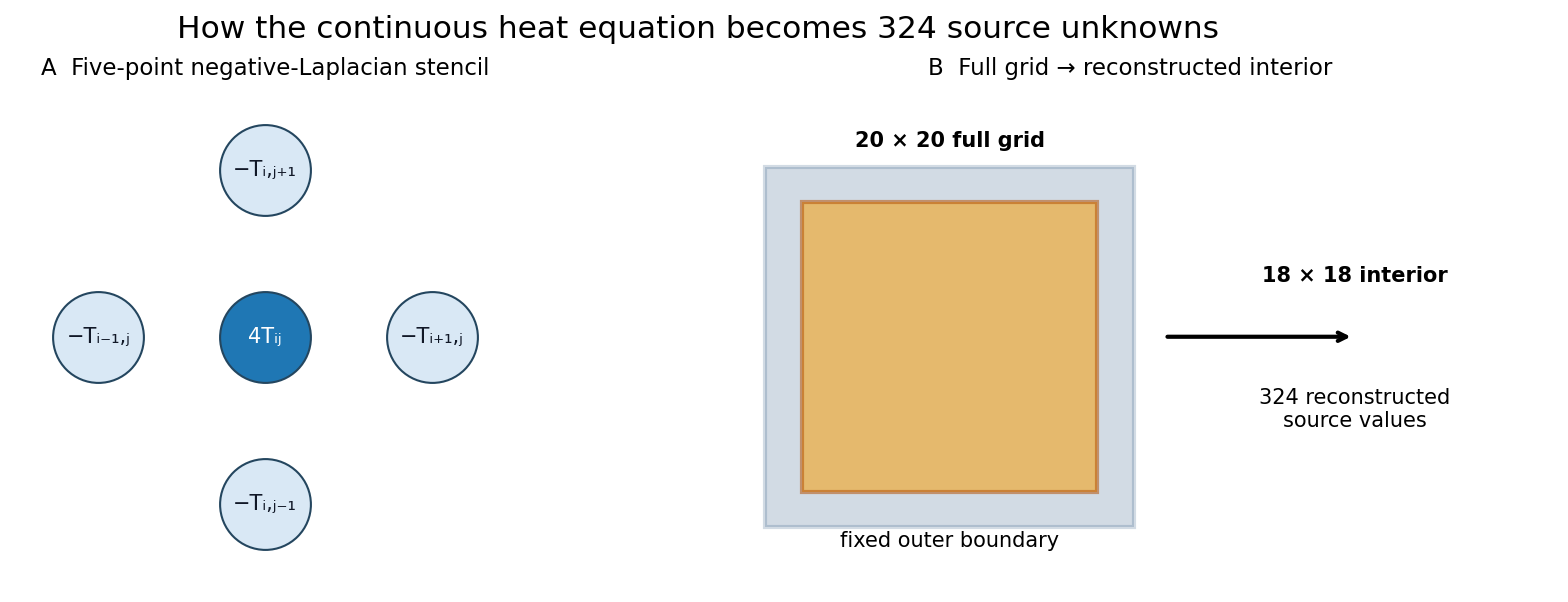

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), constrained_layout=True)
axes[0].set_aspect('equal'); axes[0].set_xlim(-1.5,1.5); axes[0].set_ylim(-1.5,1.5); axes[0].axis('off')
for x,y,label,color in [(0,0,'4Tᵢⱼ','#1f77b4'),(1,0,'−Tᵢ₊₁,ⱼ','#d9e8f5'),(-1,0,'−Tᵢ₋₁,ⱼ','#d9e8f5'),(0,1,'−Tᵢ,ⱼ₊₁','#d9e8f5'),(0,-1,'−Tᵢ,ⱼ₋₁','#d9e8f5')]:
    axes[0].scatter(x,y,s=1900,color=color,edgecolor='#24465f'); axes[0].text(x,y,label,ha='center',va='center',color='white' if (x,y)==(0,0) else '#111827',fontsize=10)
axes[0].set_title('A  Five-point negative-Laplacian stencil')
axes[1].add_patch(plt.Rectangle((.08,.12),.5,.72,facecolor='#1f4e78',alpha=.2,edgecolor='#1f4e78',lw=2)); axes[1].add_patch(plt.Rectangle((.13,.19),.4,.58,facecolor='#f59e0b',alpha=.55,edgecolor='#b45309',lw=2)); axes[1].text(.33,.88,'20 × 20 full grid',ha='center',weight='bold'); axes[1].text(.33,.08,'fixed outer boundary',ha='center'); axes[1].annotate('',xy=(.88,.5),xytext=(.62,.5),arrowprops={'arrowstyle':'->','lw':2}); axes[1].text(.88,.61,'18 × 18 interior',ha='center',weight='bold'); axes[1].text(.88,.32,'324 reconstructed\nsource values',ha='center'); axes[1].set(xlim=(0,1.15),ylim=(0,1)); axes[1].axis('off'); axes[1].set_title('B  Full grid → reconstructed interior')
fig.suptitle('How the continuous heat equation becomes 324 source unknowns'); render(fig,'02_physics_grid_stencil')
record_check('Physics model','PASS','Equation, boundary, five-point stencil, and 324-unknown interpretation rendered.')

### What the user sees
Panel A connects every interior source pixel to the center temperature and four neighbors. Panel B separates the prescribed boundary from the 324 reconstructed interior pixels.

### What it means
The discretization turns the PDE into a linear operator. The forward model is $A\mathbf t=\mathbf q$, so $\mathbf t=A^{-1}\mathbf q$: start from a source vector and calculate the complete temperature field.

### What it does not prove
Grid pixels are model parameters, not individually identified physical heaters; spatial resolution remains limited by conduction, sensing, and model assumptions.

### 2.4 Sensor measurement model

$$\mathbf y=H\mathbf t+\boldsymbol\varepsilon=HA^{-1}\mathbf q+\boldsymbol\varepsilon=G\mathbf q+\boldsymbol\varepsilon,\qquad G=HA^{-1}.$$

$\mathbf y$ contains sensor temperatures, $H$ selects sensor locations, $G$ maps source pixels to sensors, and $\boldsymbol\varepsilon$ is noise. Each column of $G$ describes how one possible source pixel affects all sensors; each row describes how one sensor responds to every source pixel. In the showcase, $G\in\mathbb R^{64\times324}$: 64 values estimate 324 source pixels, so the inverse problem is underdetermined.

### 2.5 Controlled synthetic noise

$$\boldsymbol\varepsilon\sim\mathcal N(0,\sigma^2I),\qquad \sigma=\eta\max_j|y_j|.$$

At 2% noise, the Gaussian standard deviation is 2% of the largest clean measured temperature magnitude. This is controlled synthetic noise, not a complete experimental uncertainty model.

### 2.6 Why inversion is difficult

**compact source → conductive blur → sparse noisy sensors → non-unique inverse problem → regularized estimate**

Conduction smooths source information, sparse sensors observe only part of the field, and inversion can amplify noise. Multiple sources can reproduce similar sensor values. Regularization does not recreate missing information; it selects one stable, plausible solution.

### 2.7 Regularization models

Identity Tikhonov controls overall magnitude:
$$\hat{\mathbf q}_I=\arg\min_{\mathbf q}\left[\tfrac12\|G\mathbf q-\mathbf y\|_2^2+\tfrac\alpha2\|\mathbf q\|_2^2\right]=(G^\top G+\alpha I)^{-1}G^\top\mathbf y.$$
It is a fast baseline but may be negative and oscillatory. Smoothness Tikhonov penalizes neighboring differences through $L$:
$$\hat{\mathbf q}_S=\arg\min_{\mathbf q}\left[\tfrac12\|G\mathbf q-\mathbf y\|_2^2+\tfrac\alpha2\|L\mathbf q\|_2^2\right]=(G^\top G+\alpha L^\top L)^{-1}G^\top\mathbf y.$$
$\alpha$ balances fit and smoothness: too small follows noise; too large over-smooths. The recommended showcase method adds $\mathbf q\ge0$:
$$\hat{\mathbf q}_{S+}=\arg\min_{\mathbf q\ge0}\left[\tfrac12\|G\mathbf q-\mathbf y\|_2^2+\tfrac\alpha2\|L\mathbf q\|_2^2\right].$$
Compact nonnegative additionally uses $\beta\|\mathbf q\|_1$ to promote isolated support; use it only when compact sources are physically justified because it adds tuning and runtime.

### 2.8 Metric reference

Relative source error: $e_{\mathrm{rel}}=\|\hat{\mathbf q}-\mathbf q_{\mathrm{true}}\|_2/\|\mathbf q_{\mathrm{true}}\|_2$; RMSE: $\sqrt{N^{-1}\sum_i(\hat q_i-q_i)^2}$. These require source truth. Sensor residual: $\mathbf r=G\hat{\mathbf q}-\mathbf y$; relative residual: $\rho_{\mathrm{rel}}=\|\mathbf r\|_2/\|\mathbf y\|_2$; residual RMS: $\mathrm{RMS}_r=\|\mathbf r\|_2/\sqrt m$. Measurement ratio is $\rho_m=m/n$. Peak distance is $d_{\mathrm{peak}}=\sqrt{(i_{\mathrm{pred}}-i_{\mathrm{true}})^2+(j_{\mathrm{pred}}-j_{\mathrm{true}})^2}$ in grid cells, not meters. A low sensor residual does not prove a low source error.

## 3. Package workflow and logical architecture

The workflow describes what the user does; the architecture shows which package layers carry each output to the next step.

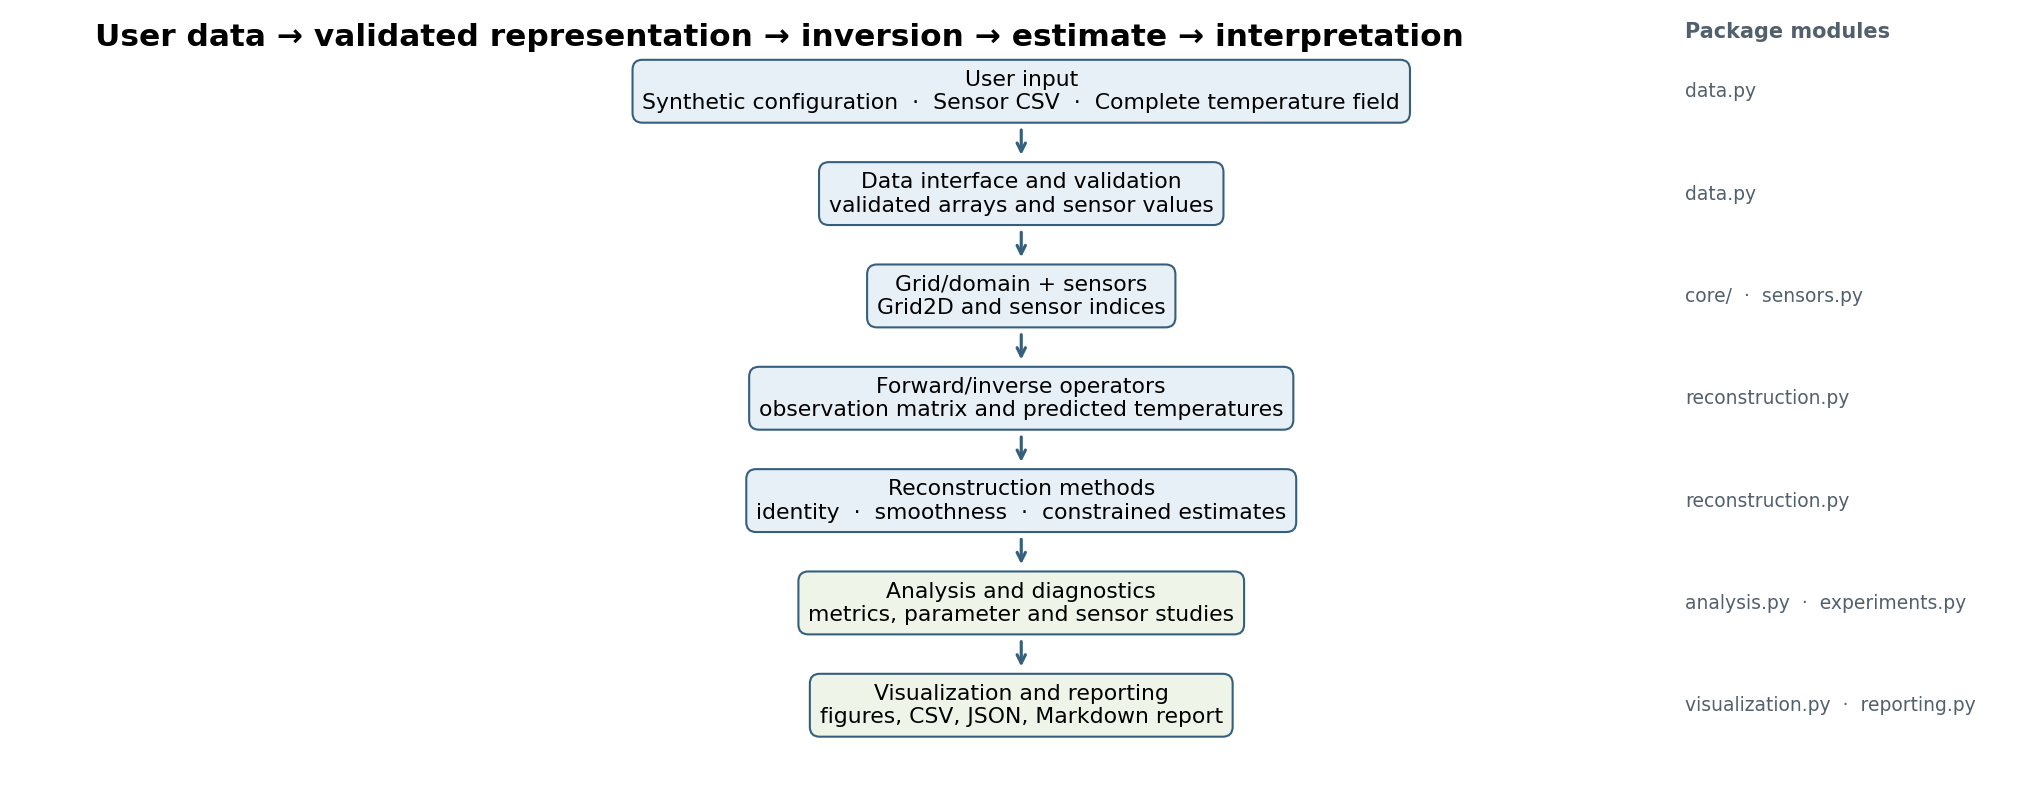

In [5]:
fig, ax = plt.subplots(figsize=(13.5, 5.2), constrained_layout=True); ax.axis('off')
levels = [
 ('User input', 'Synthetic configuration  ·  Sensor CSV  ·  Complete temperature field', 'data.py'),
 ('Data interface and validation', 'validated arrays and sensor values', 'data.py'),
 ('Grid/domain + sensors', 'Grid2D and sensor indices', 'core/  ·  sensors.py'),
 ('Forward/inverse operators', 'observation matrix and predicted temperatures', 'reconstruction.py'),
 ('Reconstruction methods', 'identity  ·  smoothness  ·  constrained estimates', 'reconstruction.py'),
 ('Analysis and diagnostics', 'metrics, parameter and sensor studies', 'analysis.py  ·  experiments.py'),
 ('Visualization and reporting', 'figures, CSV, JSON, Markdown report', 'visualization.py  ·  reporting.py'),
]
ys = np.linspace(.9, .1, len(levels))
for idx, ((title, output, modules), y) in enumerate(zip(levels, ys)):
    ax.text(.5, y, title + '\n' + output, ha='center', va='center', fontsize=10.5, bbox={'boxstyle':'round,pad=.45','facecolor':'#e7f0f7' if idx < 5 else '#eef5e8','edgecolor':'#365f7d'})
    ax.text(.83, y, modules, ha='left', va='center', fontsize=9, color='#52606d')
    if idx < len(levels)-1: ax.annotate('', xy=(.5, ys[idx+1]+.045), xytext=(.5, y-.045), arrowprops={'arrowstyle':'->','lw':1.5,'color':'#365f7d'})
ax.text(.38, .99, 'User data → validated representation → inversion → estimate → interpretation', ha='center', va='top', fontsize=15, weight='bold')
ax.text(.83, .97, 'Package modules', fontsize=10, weight='bold', color='#52606d')
render(fig, '01_architecture_workflow'); record_check('Architecture', 'PASS', 'Workflow-to-module mapping rendered.')

### What the user sees
Three supported inputs converge on validation, grid and sensor representations, inverse operators, reconstruction, diagnostics, and report artifacts. Module names appear beside the user-facing stages.

### What it means
Each layer produces the next layer's input while public APIs hide matrix assembly and solver details. Workflow and architecture are related but not identical: one describes the user's actions; the other assigns software responsibility.

### What it does not prove
A clean software flow cannot by itself guarantee uniqueness or experimental validity; those depend on physics, data quality, and sensor information.

## 4. Use case 1 — validate with known synthetic truth

### User situation
I know the source in a synthetic benchmark.

### User goal
Check whether the package can recover and localize it from sparse, noisy temperatures.

### Package action
Simulate a centered Gaussian on a 20 × 20 grid, sample 64 center-focused sensors, add 2% controlled noise, and reconstruct with smooth nonnegative regularization at $\alpha=10^{-9}$. Seeds 10, 20, and 30 test stability; the median run is displayed.

### Result

Metric,Value,Meaning
Interior source unknowns,324,18 × 18 interior
Measurements,64,19.75% of unknown count
Median relative source error,18.54%,three seeds
Largest tested source error,23.63%,three seeds
Median peak distance,1.000e+00,grid cells
Minimum reconstructed source,≈ 0,nonnegative constraint


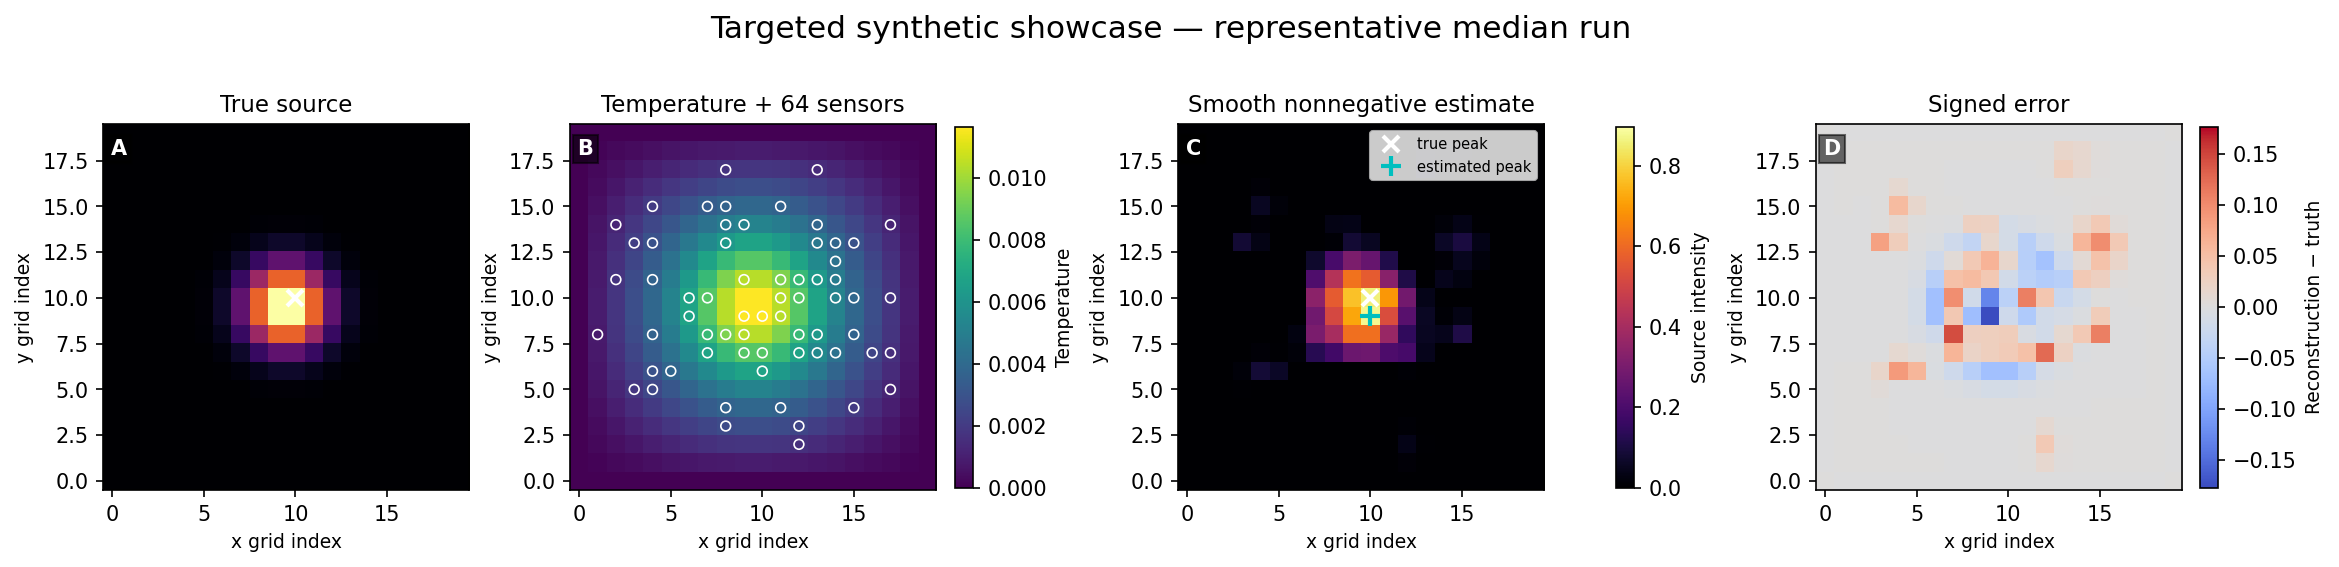

In [6]:
showcase_runs = []
for run_seed in (10, 20, 30):
    base = run_synthetic_benchmark(grid_shape=(20,20), source_type='gaussian', sensor_strategy='center_focused', num_sensors=64, noise_level=.02, alpha=1e-7, regularization='identity', seed=run_seed)
    rec = reconstruct_smooth_tikhonov(base.sensor_data_noisy, base.grid, alpha=1e-9, nonnegative=True)
    showcase_runs.append({'Seed':run_seed, 'base':base, 'reconstruction':rec, **metrics_with_truth(base.true_source, rec, base.sensor_data_noisy.values)})
showcase_stability = pd.DataFrame([{k:v for k,v in run.items() if k not in ('base','reconstruction')} for run in showcase_runs])
median_error = float(showcase_stability.relative_l2_error.median()); worst_error = float(showcase_stability.relative_l2_error.max())
representative = min(showcase_runs, key=lambda row: abs(row['relative_l2_error']-median_error))
showcase_base, showcase_reconstruction = representative['base'], representative['reconstruction']
showcase_card = pd.DataFrame([
 ('Interior source unknowns','324','18 × 18 interior'), ('Measurements','64','19.75% of unknown count'),
 ('Median relative source error',median_error,'three seeds'), ('Largest tested source error',worst_error,'three seeds'),
 ('Median peak distance',float(showcase_stability.peak_distance.median()),'grid cells'), ('Minimum reconstructed source','≈ 0','nonnegative constraint')
], columns=['Metric','Value','Meaning'])
display(table(showcase_card, {'Value': lambda x: f'{x:.2%}' if isinstance(x,float) and x > .01 and x < 1 else (f'{x:.3e}' if isinstance(x,float) else x)}))
truth, estimate = showcase_base.true_source, showcase_reconstruction.source; error = estimate-truth
source_max=max(float(truth.max()),float(estimate.max())); error_lim=float(np.max(np.abs(error)))
fig, axes=plt.subplots(1,4,figsize=(15.5,3.8),constrained_layout=True)
handles=[axes[0].imshow(truth.T,origin='lower',cmap='inferno',vmin=0,vmax=source_max,interpolation='none'), axes[1].imshow(showcase_base.temperature.T,origin='lower',cmap='viridis',interpolation='none'), axes[2].imshow(estimate.T,origin='lower',cmap='inferno',vmin=0,vmax=source_max,interpolation='none'), axes[3].imshow(error.T,origin='lower',cmap='coolwarm',vmin=-error_lim,vmax=error_lim,interpolation='none')]
titles=['True source','Temperature + 64 sensors','Smooth nonnegative estimate','Signed error']
for k,(ax,title) in enumerate(zip(axes,titles)): ax.set(title=title,xlabel='x grid index',ylabel='y grid index'); panel(ax,'ABCD'[k])
idx=showcase_base.sensor_data_noisy.indices; axes[1].scatter(idx[:,0],idx[:,1],facecolors='none',edgecolors='white',s=22,lw=.8)
ti,tj=peak_index(truth); ri,rj=peak_index(estimate); axes[0].plot(ti,tj,'wx',ms=8,mew=2); axes[2].plot(ti,tj,'wx',ms=8,mew=2,label='true peak'); axes[2].plot(ri,rj,'c+',ms=10,mew=2,label='estimated peak'); axes[2].legend(fontsize=7)
fig.colorbar(handles[0],ax=[axes[0],axes[2]],shrink=.72,label='Source intensity'); fig.colorbar(handles[1],ax=axes[1],shrink=.72,label='Temperature'); fig.colorbar(handles[3],ax=axes[3],shrink=.72,label='Reconstruction − truth')
fig.suptitle('Targeted synthetic showcase — representative median run'); render(fig,'02_targeted_showcase')
assert representative['Seed']==10 and abs(median_error-.1853525)<.002 and abs(worst_error-.2363373)<.002 and showcase_stability.minimum_source.min()>=-1e-10
record_check('Synthetic showcase','PASS',f'Median {median_error:.2%}; largest tested {worst_error:.2%}; peak median {showcase_stability.peak_distance.median():.1f} cell.')

### What the user sees
Panel A is known synthetic truth, B is the broader temperature effect with 64 sensor markers, C is the smooth nonnegative estimate, and D is signed error. The white × marks truth and the cyan + marks the reconstructed peak. Source and temperature are different quantities and must not be compared by brightness across panels.

### What it means
The source peak was localized within one grid cell in the targeted synthetic showcase. Signed error = reconstruction − truth: blue underestimates, red overestimates, and pale regions are close to truth.

### What it does not prove
This is a targeted center-focused design and not a universal unknown-location solution. The recovered amplitude and width remain imperfect.

## 5. Which reconstruction method should the user choose?

All methods below use the identical representative measurements. This is a configured comparison, not a universal ranking.

Method,Relative source error,Minimum source,Near-zero fraction,Runtime (ms)
Identity,66.480%,-3.467e-01,0.0%,10.9
Smoothness,36.274%,-1.983e-01,0.0%,11.6
Smooth nonnegative,18.535%,5.105e-11,5.9%,87.1
Compact nonnegative,18.547%,0.000e+00,73.5%,273.9


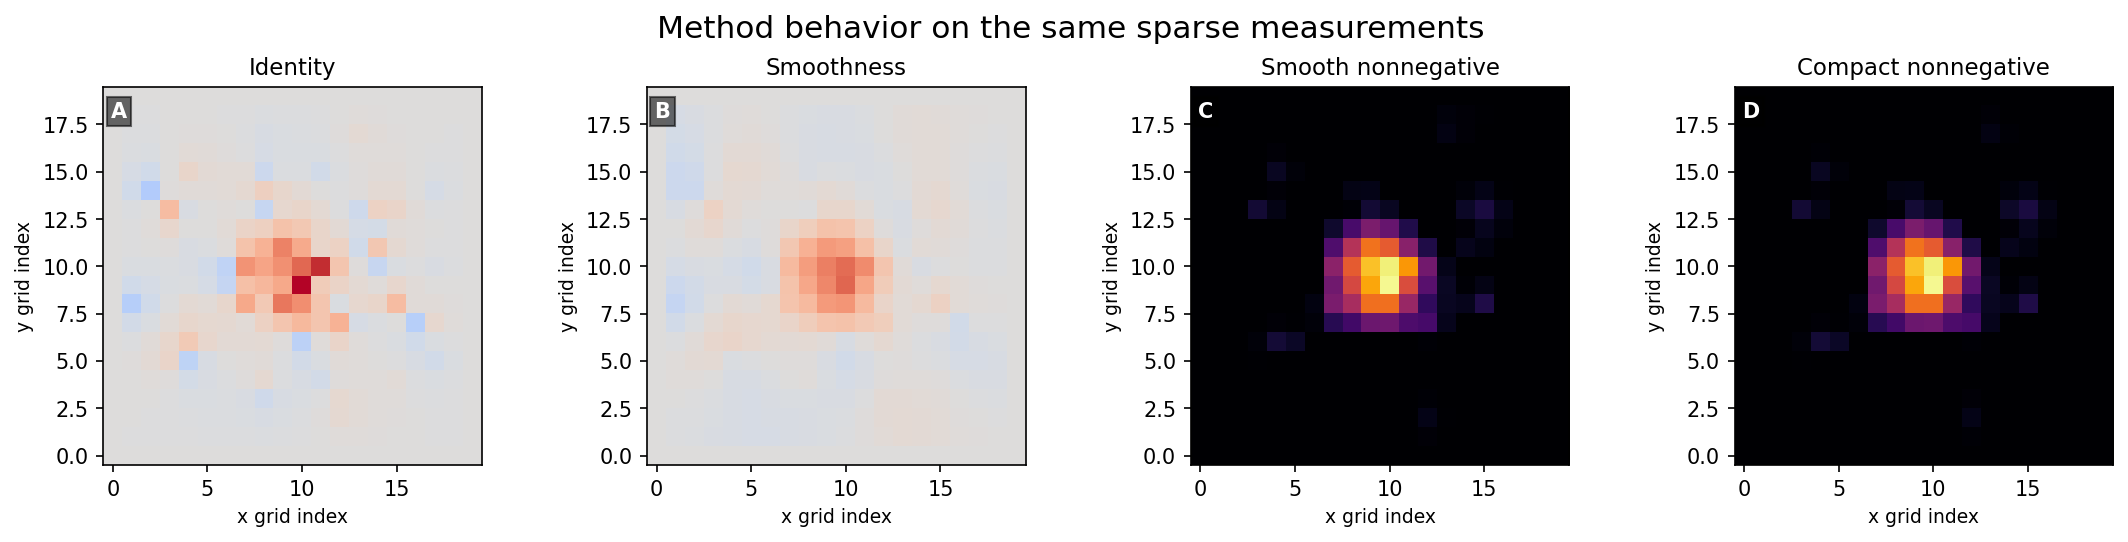

In [7]:
method_recs={
 'Identity':showcase_base.reconstruction,
 'Smoothness':reconstruct_smooth_tikhonov(showcase_base.sensor_data_noisy,showcase_base.grid,alpha=1e-9,nonnegative=False),
 'Smooth nonnegative':showcase_reconstruction,
 'Compact nonnegative':reconstruct_compact_nonnegative(showcase_base.sensor_data_noisy,showcase_base.grid,alpha=1e-9,beta=1e-8,max_iterations=100000,tolerance=1e-7)}
method_rows=[]
for name,rec in method_recs.items():
    m=metrics_with_truth(showcase_base.true_source,rec,showcase_base.sensor_data_noisy.values)
    method_rows.append({'Method':name,'Relative source error':m['relative_l2_error'],'Minimum source':m['minimum_source'],'Near-zero fraction':m['near_zero_fraction'],'Runtime (ms)':1000*m['runtime']})
method_table=pd.DataFrame(method_rows); display(table(method_table,{'Relative source error':'{:.3%}','Minimum source':'{:.3e}','Near-zero fraction':'{:.1%}','Runtime (ms)':'{:.1f}'}))
fig,axes=plt.subplots(1,4,figsize=(14.5,3.5),constrained_layout=True); signed=max(float(np.max(np.abs(r.source))) for r in method_recs.values()); positive=max(float(showcase_base.true_source.max()),float(method_recs['Compact nonnegative'].source.max()))
for k,(ax,(name,rec)) in enumerate(zip(axes,method_recs.items())):
    if 'nonnegative' in name.lower(): im=ax.imshow(rec.source.T,origin='lower',cmap='inferno',vmin=0,vmax=positive,interpolation='none')
    else: im=ax.imshow(rec.source.T,origin='lower',cmap='coolwarm',vmin=-signed,vmax=signed,interpolation='none')
    ax.set(title=name,xlabel='x grid index',ylabel='y grid index'); panel(ax,'ABCD'[k])
fig.suptitle('Method behavior on the same sparse measurements'); render(fig,'03_method_choice')
assert abs(method_table.loc[method_table.Method=='Smooth nonnegative','Relative source error'].iloc[0]-.18535)<.002
record_check('Method choice','PASS','Smooth nonnegative is the recommended simpler and faster physical method here.')

### What the user sees
The table compares error, physical sign, concentration, and runtime on identical measurements. The signed panels use a shared zero-centered scale; nonnegative methods use a shared nonnegative scale.

### What it means
Identity is fast but oscillatory; smoothness remains signed. The difference between 18.535% and 18.547% is not meaningful. Smooth nonnegative is recommended because it is simpler and faster for this scenario.

### What it does not prove
This configured comparison is not a universal ranking. Compact support or signed physics may justify a different method elsewhere.

### Alpha sensitivity — selecting the fit/smoothness trade-off

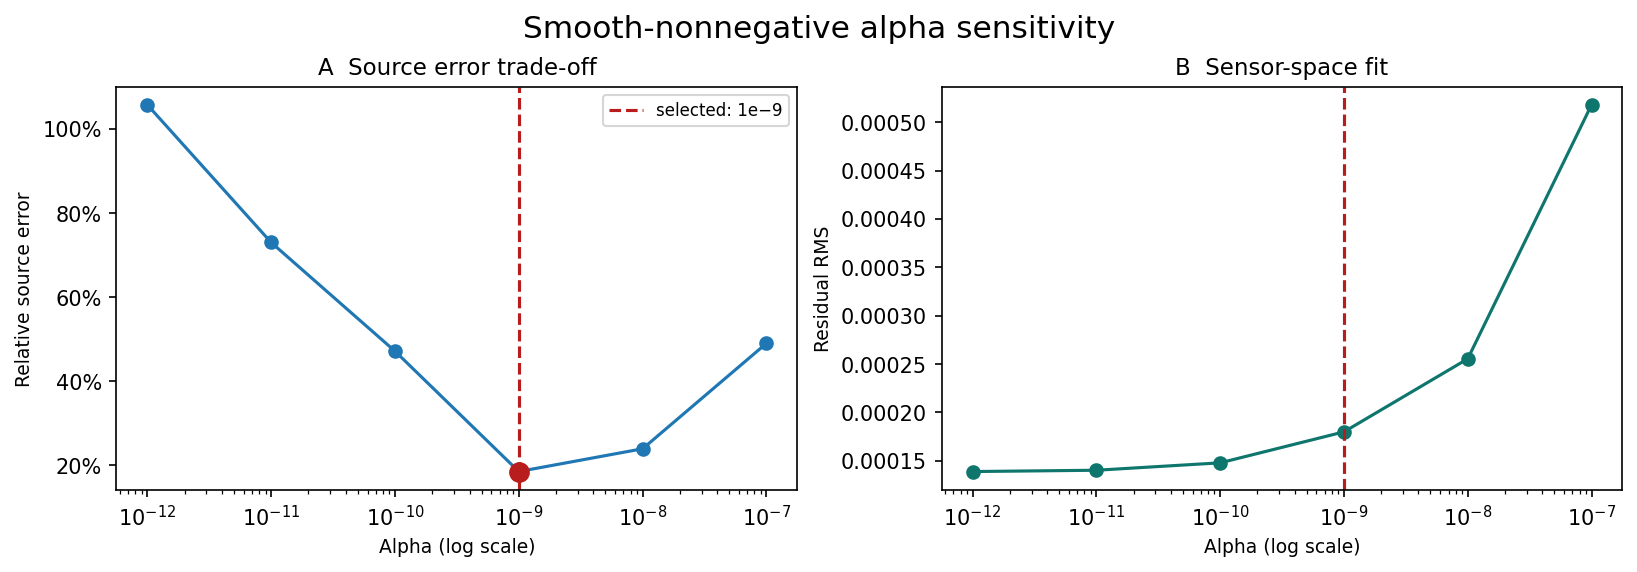

In [8]:
alpha_values=np.array([1e-12,1e-11,1e-10,1e-9,1e-8,1e-7]); alpha_rows=[]
for alpha in alpha_values:
    rec=reconstruct_smooth_tikhonov(showcase_base.sensor_data_noisy,showcase_base.grid,alpha=alpha,nonnegative=True); m=metrics_with_truth(showcase_base.true_source,rec,showcase_base.sensor_data_noisy.values); alpha_rows.append({'Alpha':alpha,'Relative source error':m['relative_l2_error'],'Sensor residual RMS':m['residual_rms']})
alpha_study=pd.DataFrame(alpha_rows); best_alpha=float(alpha_study.loc[alpha_study['Relative source error'].idxmin(),'Alpha'])
fig,axes=plt.subplots(1,2,figsize=(10.8,3.7),constrained_layout=True); axes[0].semilogx(alpha_study.Alpha,alpha_study['Relative source error'],'o-',color='#1f77b4'); axes[0].axvline(1e-9,color='#b91c1c',ls='--',label='selected: 1e−9'); axes[0].scatter([1e-9],[alpha_study.loc[alpha_study.Alpha==1e-9,'Relative source error'].iloc[0]],s=80,color='#b91c1c',zorder=3); axes[0].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1)); axes[0].set(title='A  Source error trade-off',xlabel='Alpha (log scale)',ylabel='Relative source error'); axes[0].legend(fontsize=8)
axes[1].semilogx(alpha_study.Alpha,alpha_study['Sensor residual RMS'],'o-',color='#0f766e'); axes[1].axvline(1e-9,color='#b91c1c',ls='--'); axes[1].set(title='B  Sensor-space fit',xlabel='Alpha (log scale)',ylabel='Residual RMS'); fig.suptitle('Smooth-nonnegative alpha sensitivity'); render(fig,'04_alpha_sensitivity')
assert best_alpha==1e-9; record_check('Alpha sensitivity','PASS','1e-9 is the best tested alpha for this exact configuration.')

### What the user sees
Panel A plots source error and panel B plots sensor residual RMS across six orders of magnitude; the red marker highlights $10^{-9}$.

### What it means
$10^{-9}$ is the best tested alpha for this exact configuration. Alpha is selected through a tested trade-off, not guessed.

### What it does not prove
The selected value is not universal; changes in noise, layout, grid, or source physics can move the useful range.

## 6. Sensor planning and robustness

How many sensors are useful, and how should they be placed? The budget study uses regular coverage; the positional audit compares center-focused, regular, and random 64-sensor layouts across four source locations. All use 2% noise, smooth nonnegative reconstruction, $\alpha=10^{-9}$, and seeds 10, 20, and 30.

Study,Scenario,Median,Largest_tested
Sensor budget,16 sensors,62.9%,68.5%
Sensor budget,36 sensors,31.7%,33.9%
Sensor budget,64 sensors,28.8%,34.5%
Sensor budget,81 sensors,24.4%,24.8%
Layout audit,Center-focused,22.6%,59.6%
Layout audit,Regular,27.0%,32.6%
Layout audit,Random,25.9%,33.5%


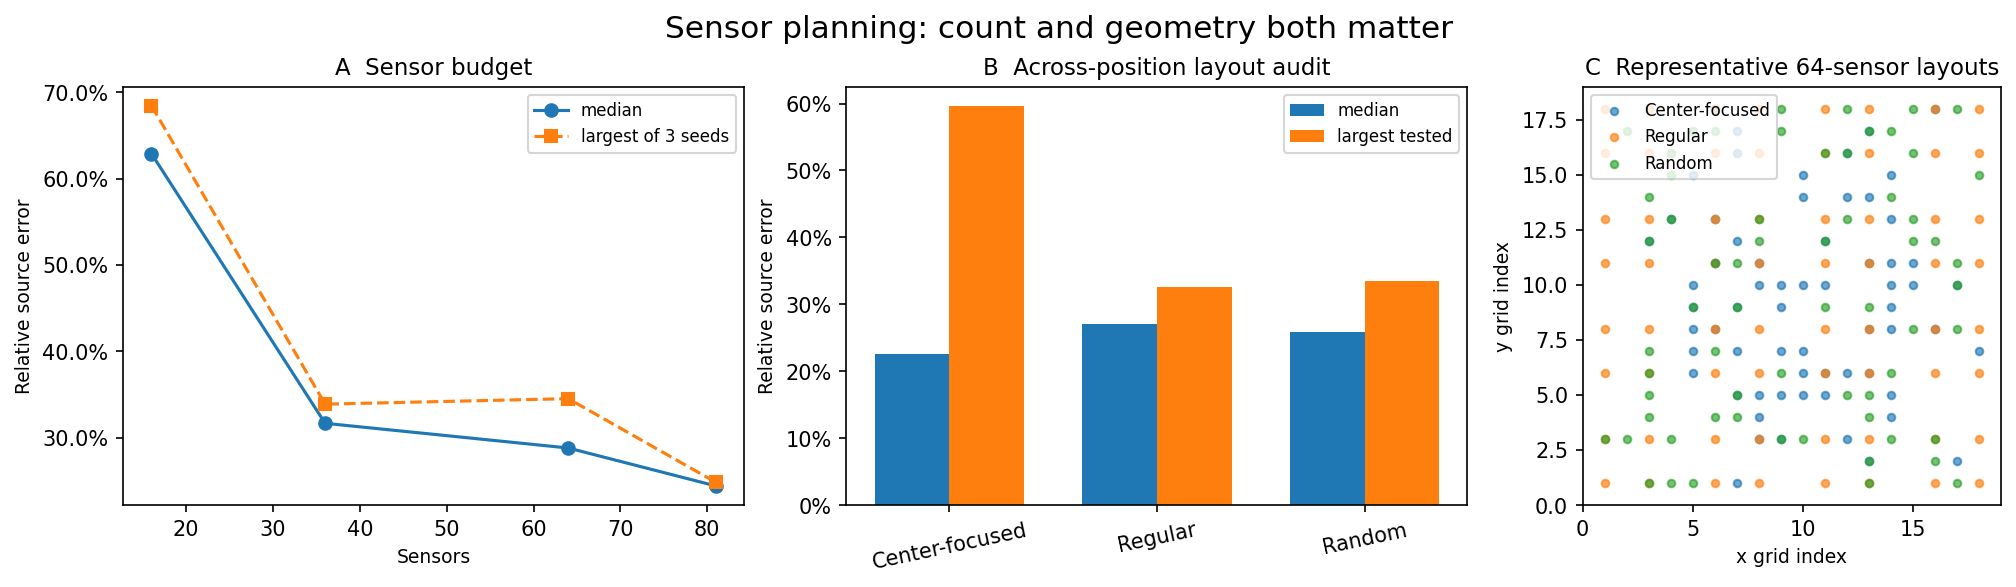

In [9]:
planning_grid=Grid2D(nx=20,ny=20); budget_rows=[]
for count in (16,36,64,81):
    for seed in (10,20,30):
        b=run_synthetic_benchmark(grid_shape=(20,20),source_type='gaussian',sensor_strategy='regular',num_sensors=count,noise_level=.02,alpha=1e-7,seed=seed); r=reconstruct_smooth_tikhonov(b.sensor_data_noisy,b.grid,alpha=1e-9,nonnegative=True); m=metrics_with_truth(b.true_source,r,b.sensor_data_noisy.values); budget_rows.append({'Sensors':count,'Seed':seed,'Error':m['relative_l2_error']})
budget=pd.DataFrame(budget_rows).groupby('Sensors',sort=False).agg(Median=('Error','median'),Largest_tested=('Error','max')).reset_index()
positions={'central':(.5,.5),'lower left':(.25,.3),'lower right':(.75,.3),'upper right':(.7,.75)}; placers={'Center-focused':center_focused_sensors,'Regular':regular_grid_sensors,'Random':random_sensors}; layout_rows=[]
for position,center in positions.items():
    source=gaussian_source(planning_grid,center=center,amplitude=1,sigma=.08); temperature=solve_forward(source,planning_grid)
    for layout,placer in placers.items():
        for seed in (10,20,30):
            opts={'count':64,'include_boundary':False}; opts.update({} if layout=='Regular' else {'seed':seed}); ids=placer(planning_grid,**opts); clean=create_sensor_data(temperature,ids,planning_grid); noisy=add_noise_to_sensor_data(clean,.02,seed=1000+seed,relative=True); rec=reconstruct_smooth_tikhonov(noisy,planning_grid,alpha=1e-9,nonnegative=True); layout_rows.append({'Layout':layout,'Position':position,'Seed':seed,'Error':metrics_with_truth(source,rec,noisy.values)['relative_l2_error']})
layout_detail=pd.DataFrame(layout_rows); layouts=layout_detail.groupby('Layout',sort=False).agg(Median=('Error','median'),Largest_tested=('Error','max')).reset_index()
planning_table=pd.concat([budget.assign(Study='Sensor budget',Scenario=budget.Sensors.astype(str)+' sensors')[['Study','Scenario','Median','Largest_tested']],layouts.assign(Study='Layout audit',Scenario=layouts.Layout)[['Study','Scenario','Median','Largest_tested']]],ignore_index=True); display(table(planning_table,{'Median':'{:.1%}','Largest_tested':'{:.1%}'}))
fig,axes=plt.subplots(1,3,figsize=(14,3.8),constrained_layout=True); axes[0].plot(budget.Sensors,budget.Median,'o-',label='median'); axes[0].plot(budget.Sensors,budget.Largest_tested,'s--',label='largest of 3 seeds'); axes[0].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1)); axes[0].set(title='A  Sensor budget',xlabel='Sensors',ylabel='Relative source error'); axes[0].legend(fontsize=8)
x=np.arange(3); axes[1].bar(x-.18,layouts.Median,.36,label='median'); axes[1].bar(x+.18,layouts.Largest_tested,.36,label='largest tested'); axes[1].set_xticks(x,layouts.Layout,rotation=12); axes[1].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1)); axes[1].set(title='B  Across-position layout audit',ylabel='Relative source error'); axes[1].legend(fontsize=8)
for name,placer in placers.items(): opts={'count':64,'include_boundary':False}; opts.update({} if name=='Regular' else {'seed':10}); ids=placer(planning_grid,**opts); axes[2].scatter(ids[:,0],ids[:,1],s=13,label=name,alpha=.65)
axes[2].set(xlim=(0,19),ylim=(0,19),aspect='equal',title='C  Representative 64-sensor layouts',xlabel='x grid index',ylabel='y grid index'); axes[2].legend(fontsize=8); fig.suptitle('Sensor planning: count and geometry both matter'); render(fig,'05_sensor_planning')
assert abs(budget.loc[budget.Sensors==81,'Median'].iloc[0]-.24395)<.002 and abs(layouts.loc[layouts.Layout=='Regular','Largest_tested'].iloc[0]-.326)<.01; record_check('Sensor planning','PASS','Budget and positional layout studies reproduced.')

### What the user sees
Panels compare median and largest tested errors as sensor count changes, summarize layout robustness, and show the actual sensing geometries.

### What it means
More informative sensing generally improved this tested setup. Count and geometry both matter; regular coverage provided the best tested worst-case balance for unknown locations in this small audit.

### What it does not prove
The layouts are not nested, only three noise seeds were tested, and no sensor layout is universally optimal.

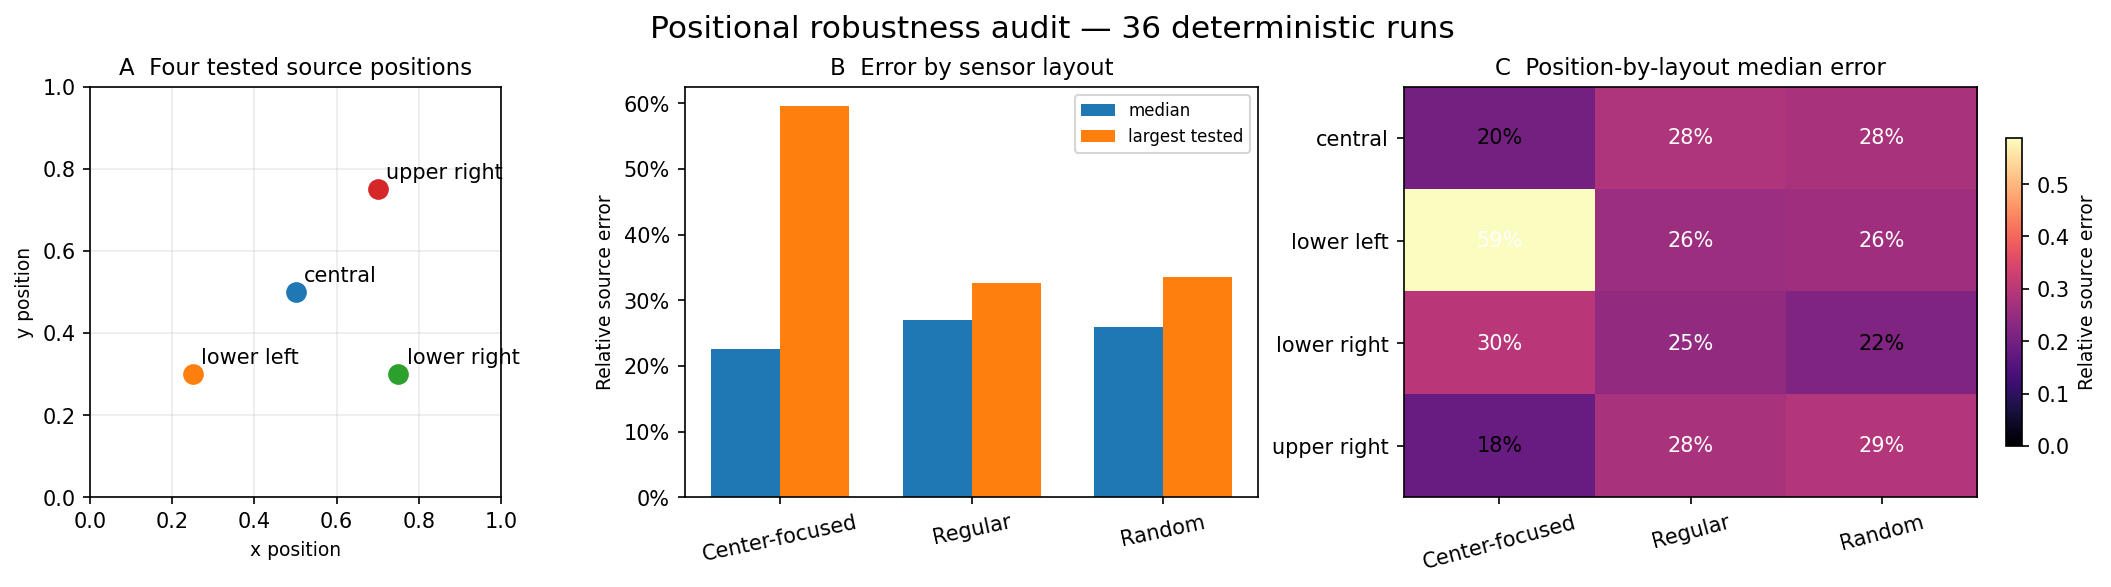

In [10]:
position_summary=layout_detail.groupby(['Position','Layout'],sort=False).agg(Median=('Error','median'),Largest_tested=('Error','max')).reset_index(); heat=position_summary.pivot(index='Position',columns='Layout',values='Median').reindex(index=positions,columns=placers)
fig,axes=plt.subplots(1,3,figsize=(14,3.8),constrained_layout=True)
for name,(x0,y0) in positions.items(): axes[0].scatter(x0,y0,s=80); axes[0].annotate(name,(x0,y0),xytext=(4,5),textcoords='offset points')
axes[0].set(xlim=(0,1),ylim=(0,1),aspect='equal',title='A  Four tested source positions',xlabel='x position',ylabel='y position'); axes[0].grid(alpha=.25)
x=np.arange(3); axes[1].bar(x-.18,layouts.Median,.36,label='median'); axes[1].bar(x+.18,layouts.Largest_tested,.36,label='largest tested'); axes[1].set_xticks(x,layouts.Layout,rotation=12); axes[1].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1)); axes[1].set(title='B  Error by sensor layout',ylabel='Relative source error'); axes[1].legend(fontsize=8)
im=axes[2].imshow(heat.to_numpy(),cmap='magma',aspect='auto',vmin=0,vmax=float(heat.max().max())); axes[2].set_xticks(range(3),heat.columns,rotation=15); axes[2].set_yticks(range(4),heat.index); axes[2].set_title('C  Position-by-layout median error')
for i in range(4):
    for j in range(3): axes[2].text(j,i,f'{heat.iloc[i,j]:.0%}',ha='center',va='center',color='white' if heat.iloc[i,j]>.22 else 'black')
fig.colorbar(im,ax=axes[2],shrink=.75,label='Relative source error'); fig.suptitle('Positional robustness audit — 36 deterministic runs'); render(fig,'06_positional_robustness')
record_check('Positional robustness','PASS','Four source positions × three layouts × three seeds rendered.')

### What the user sees
Panel A defines the four source locations, B compares layout-level median and largest tested errors, and C exposes which source/layout combinations are difficult.

### What it means
Center-focused sensing is a targeted design: strong near its favored region but less balanced elsewhere. Regular coverage gave the best tested worst-case result for unknown positions.

### What it does not prove
Four positions and three seeds are a small audit, not a universal design optimization.

### How measurement information changes the result

Case,Measurements,Relative source error,Peak distance
324 measurements,324,24.67%,1.0 cells
64 regular,64,28.48%,0.0 cells
16 regular,16,62.71%,1.0 cells


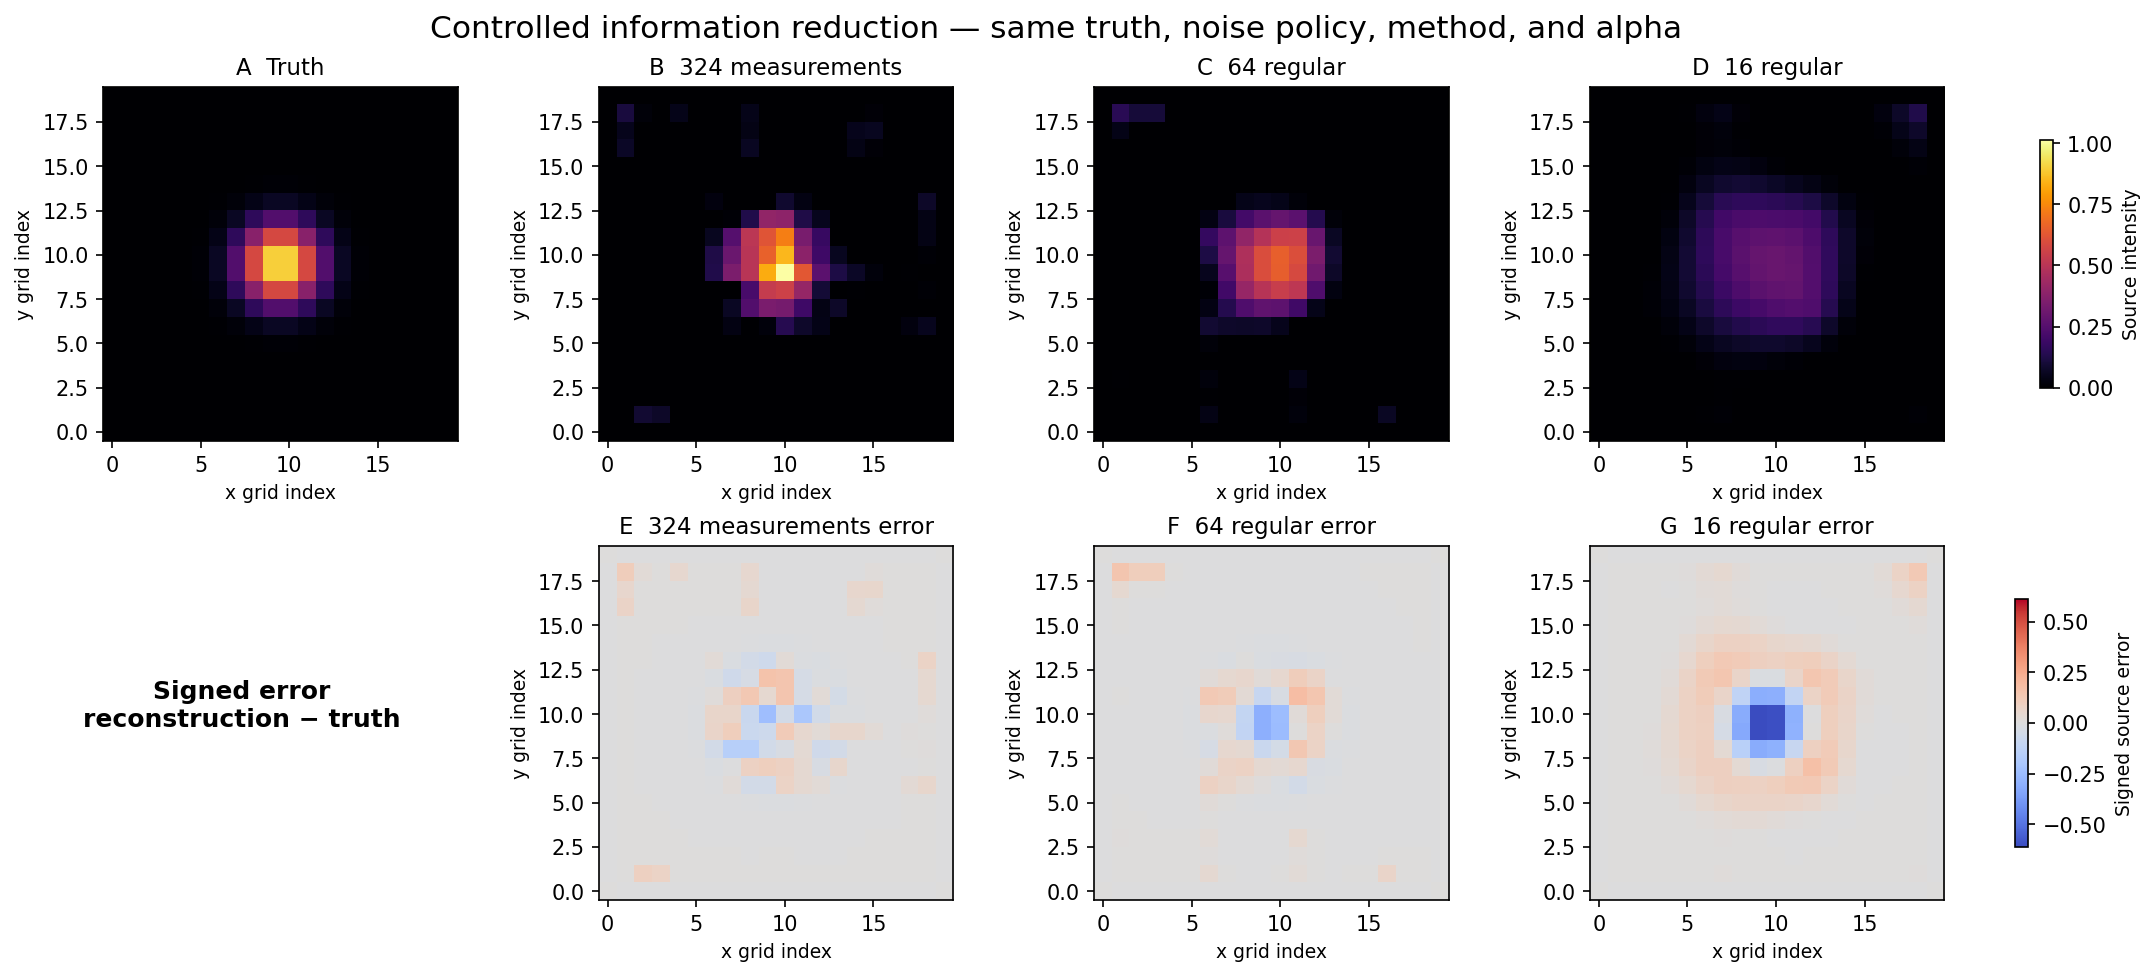

In [11]:
info_truth=gaussian_source(planning_grid,center=(.5,.5),sigma=.08); info_temperature=solve_forward(info_truth,planning_grid); all_ids=np.array([(i,j) for i in range(1,19) for j in range(1,19)]); info_cases=[('324 measurements',all_ids),('64 regular',regular_grid_sensors(planning_grid,64)),('16 regular',regular_grid_sensors(planning_grid,16))]; info_recs=[]; info_rows=[]
for label,ids in info_cases:
    clean=create_sensor_data(info_temperature,ids,planning_grid); noisy=add_noise_to_sensor_data(clean,.02,seed=1010,relative=True); rec=reconstruct_smooth_tikhonov(noisy,planning_grid,alpha=1e-9,nonnegative=True); m=metrics_with_truth(info_truth,rec,noisy.values); info_recs.append(rec); info_rows.append({'Case':label,'Measurements':len(ids),'Relative source error':m['relative_l2_error'],'Peak distance':m['peak_distance']})
information_table=pd.DataFrame(info_rows); display(table(information_table,{'Relative source error':'{:.2%}','Peak distance':'{:.1f} cells'}))
sources=[info_truth]+[r.source for r in info_recs]; errors=[r.source-info_truth for r in info_recs]; vmax=max(float(x.max()) for x in sources); elim=max(float(np.max(np.abs(x))) for x in errors); fig,axes=plt.subplots(2,4,figsize=(14.5,6.4),constrained_layout=True); names=['Truth']+[x[0] for x in info_cases]
for k,(ax,field,name) in enumerate(zip(axes[0],sources,names)): im=ax.imshow(field.T,origin='lower',cmap='inferno',vmin=0,vmax=vmax,interpolation='none'); ax.set(title=f'{chr(65+k)}  {name}',xlabel='x grid index',ylabel='y grid index')
axes[1,0].axis('off'); axes[1,0].text(.5,.55,'Signed error\nreconstruction − truth',ha='center',va='center',fontsize=12,weight='bold')
for k,(ax,field,name) in enumerate(zip(axes[1,1:],errors,[x[0] for x in info_cases])): eim=ax.imshow(field.T,origin='lower',cmap='coolwarm',vmin=-elim,vmax=elim,interpolation='none'); ax.set(title=f'{chr(69+k)}  {name} error',xlabel='x grid index',ylabel='y grid index')
fig.colorbar(im,ax=axes[0].tolist(),shrink=.7,label='Source intensity'); fig.colorbar(eim,ax=axes[1,1:].tolist(),shrink=.7,label='Signed source error'); fig.suptitle('Controlled information reduction — same truth, noise policy, method, and alpha'); render(fig,'07_information_reduction')
record_check('Information reduction','PASS','324/64/16 measurement comparison rendered with common and symmetric limits.')

### What the user sees
The upper row uses a common source scale for truth and three reconstructions; the lower row uses one symmetric error scale. Signed error = reconstruction − truth: blue underestimates, red overestimates, pale is close.

### What it means
Reducing measurement information broadens the estimate and removes source detail. The 16-sensor case explains why sensor information matters; it is not the main success result.

### What it does not prove
The regular layouts are not nested and noise scale is recomputed for each measurement set, so this is controlled illustration rather than a universal causal law.

## 7. Use case 2 — external sparse sensor CSV

### User situation
I have sparse temperature measurements in a CSV file.

### User goal
Obtain an interpretable source estimate, sensor-space diagnostics, and an exportable report.

### Package action
Load the required `i, j, value` schema, validate it, reconstruct through the public measurement API, and apply the recommended smooth nonnegative method.

### Result

**CSV schema and first five rows**

i,j,value,x,y
1,1,0.000148,0.052632,0.052632
1,7,0.000867,0.052632,0.368421
1,12,0.000780,0.052632,0.631579
1,18,0.000118,0.052632,0.947368
7,1,0.001081,0.368421,0.052632


Method,Sensors,Sensor residual RMS,Relative residual,Minimum source
Smooth nonnegative,16,7.059e-05,1.64%,1.522e-05


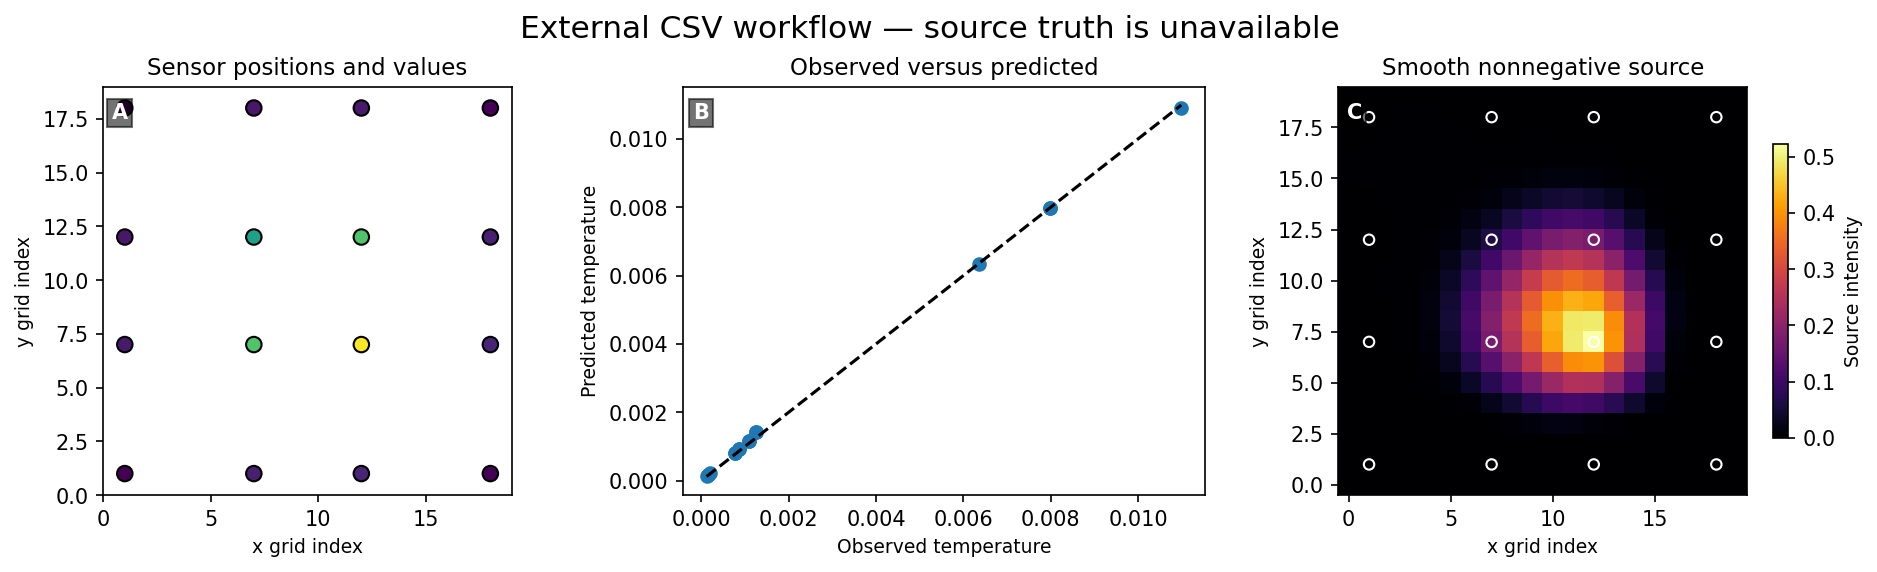

In [12]:
sensor_csv_path=PROJECT_ROOT/'examples'/'data'/'demo_sensor_measurements.csv'; csv_preview=pd.read_csv(sensor_csv_path)
display(Markdown('**CSV schema and first five rows**')); display(table(csv_preview.head(5)))
external_data=load_sensor_csv(sensor_csv_path)
external_identity=reconstruct_from_measurements(external_data,grid_shape=(20,20),alpha=1e-7,regularization='identity')
external_rec=reconstruct_smooth_tikhonov(external_data,external_identity.grid,alpha=1e-9,nonnegative=True)
external_result=MeasurementReconstructionResult(grid=external_identity.grid,sensor_data=external_data,reconstruction=external_rec,config={'mode':'external_measurements','grid_shape':[20,20],'regularization':'smooth_nonnegative','alpha':1e-9},runtime=float(external_rec.runtime))
external_diag=pd.DataFrame([{'Method':'Smooth nonnegative','Sensors':len(external_data),'Sensor residual RMS':residual_rms(external_rec.predicted_measurements,external_data.values),'Relative residual':relative_residual(external_rec.predicted_measurements,external_data.values),'Minimum source':float(external_rec.source[1:-1,1:-1].min())}])
display(table(external_diag,{'Sensor residual RMS':'{:.3e}','Relative residual':'{:.2%}','Minimum source':'{:.3e}'}))
observed=external_data.values; predicted=external_rec.predicted_measurements; fig,axes=plt.subplots(1,3,figsize=(12.5,3.7),constrained_layout=True)
axes[0].scatter(external_data.indices[:,0],external_data.indices[:,1],c=observed,cmap='viridis',s=55,edgecolor='black'); axes[0].set(xlim=(0,19),ylim=(0,19),aspect='equal',title='Sensor positions and values',xlabel='x grid index',ylabel='y grid index')
lo=min(observed.min(),predicted.min()); hi=max(observed.max(),predicted.max()); axes[1].scatter(observed,predicted,color='tab:blue'); axes[1].plot([lo,hi],[lo,hi],'k--'); axes[1].set(title='Observed versus predicted',xlabel='Observed temperature',ylabel='Predicted temperature')
im=axes[2].imshow(external_rec.source.T,origin='lower',cmap='inferno',vmin=0,interpolation='none'); axes[2].scatter(external_data.indices[:,0],external_data.indices[:,1],facecolors='none',edgecolors='white',s=25); axes[2].set(title='Smooth nonnegative source',xlabel='x grid index',ylabel='y grid index'); fig.colorbar(im,ax=axes[2],shrink=.72,label='Source intensity')
for k,ax in enumerate(axes): panel(ax,'ABC'[k])
fig.suptitle('External CSV workflow — source truth is unavailable'); render(fig,'04_external_csv')
assert {'rmse','mae','relative_l2_error'}.isdisjoint(external_result.metrics)
record_check('External CSV','PASS',f'{len(external_data)} sensors; residual RMS {external_diag.iloc[0]["Sensor residual RMS"]:.3e}; no truth-based source metrics.')

### What the user sees
Panel A maps measured sensor values, B compares observed and predicted temperatures against the ideal diagonal, and C shows the recommended smooth-nonnegative source estimate with sensor locations.

### What it means
The package turns validated CSV measurements into a regularized source estimate, sensor-fit diagnostics, and a report.

### What it does not prove
Source truth is unavailable, so source RMSE, MAE, and relative L2 are not reported. This demonstrates external-data support, not external validation.

## 8. Use case 3 — complete two-dimensional temperature field

### User situation
I have a complete two-dimensional temperature array.

### User goal
Use the array directly and inspect the reconstructed source and temperature fit.

### Package action
Pass the noisy 2D array and its `Grid2D` to `reconstruct_from_temperature_field(...)`.

### Result

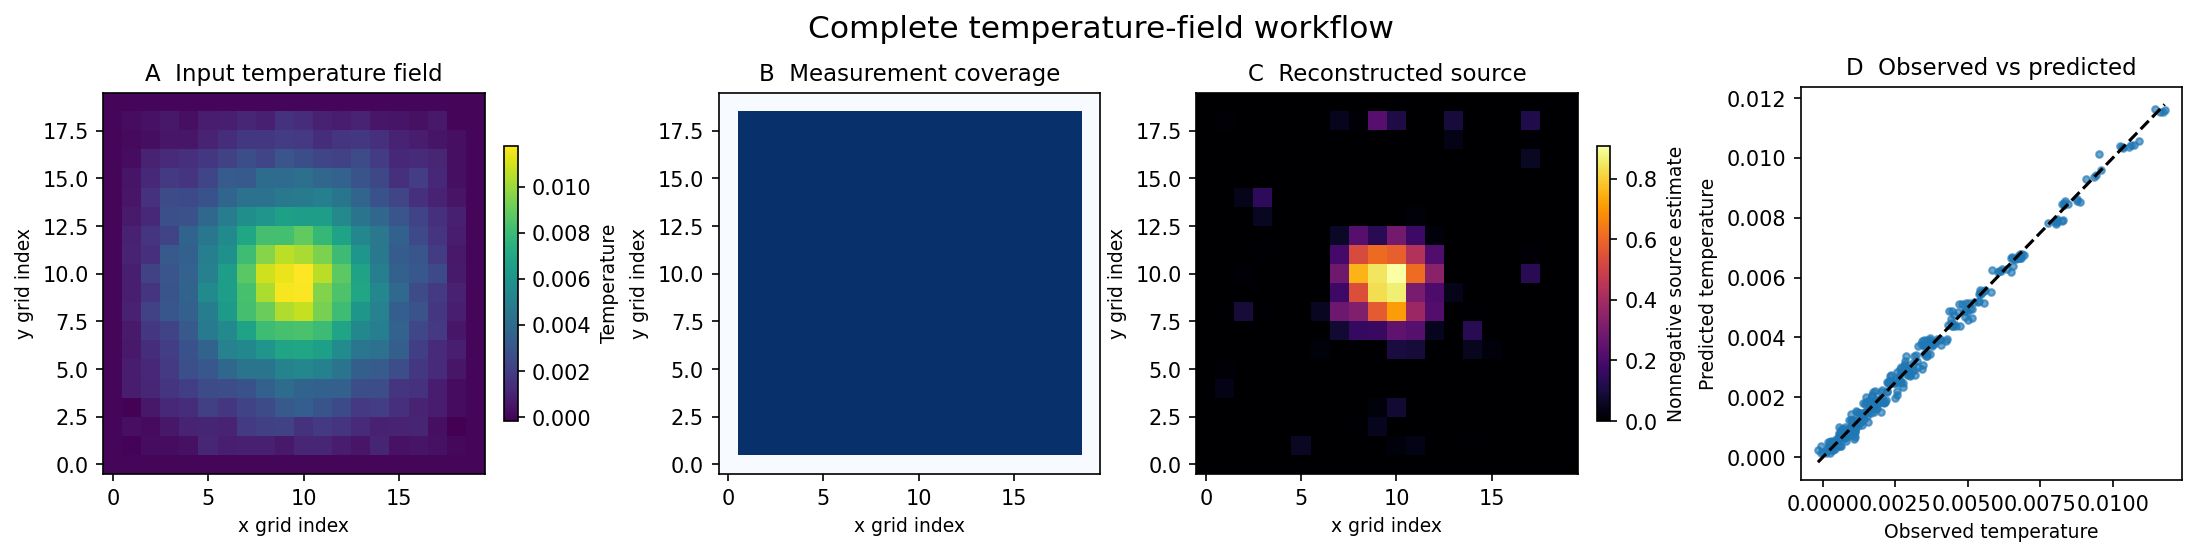

**324 interior temperatures used · sensor residual RMS = 2.236e-04.**

In [13]:
field_grid=Grid2D(nx=20,ny=20); field_truth=gaussian_source(field_grid,center=(.5,.5),sigma=.08); clean_field=solve_forward(field_truth,field_grid)
rng=np.random.default_rng(2026); noisy_field=clean_field.copy(); field_sigma=.02*float(np.max(np.abs(clean_field[1:-1,1:-1]))); noisy_field[1:-1,1:-1]+=rng.normal(0,field_sigma,size=(18,18))
field_ingestion=reconstruct_from_temperature_field(noisy_field,grid=field_grid,alpha=1e-9,regularization='smoothness')
field_physical=reconstruct_smooth_tikhonov(field_ingestion.sensor_data,field_grid,alpha=1e-9,nonnegative=True)
field_result=MeasurementReconstructionResult(grid=field_grid,sensor_data=field_ingestion.sensor_data,reconstruction=field_physical,config={'mode':'temperature_field','grid_shape':[20,20],'regularization':'smooth_nonnegative','alpha':1e-9},runtime=float(field_physical.runtime))
field_observed=field_result.sensor_data.values; field_predicted=field_result.reconstruction.predicted_measurements
fig,axes=plt.subplots(1,4,figsize=(14.5,3.6),constrained_layout=True)
a=axes[0].imshow(noisy_field.T,origin='lower',cmap='viridis',interpolation='none'); fig.colorbar(a,ax=axes[0],shrink=.7,label='Temperature')
coverage=np.zeros((20,20)); ids=field_result.sensor_data.indices; coverage[ids[:,0],ids[:,1]]=1; axes[1].imshow(coverage.T,origin='lower',cmap='Blues',vmin=0,vmax=1,interpolation='none')
c=axes[2].imshow(field_result.reconstructed_source.T,origin='lower',cmap='inferno',vmin=0,interpolation='none'); fig.colorbar(c,ax=axes[2],shrink=.7,label='Nonnegative source estimate')
lo=min(field_observed.min(),field_predicted.min()); hi=max(field_observed.max(),field_predicted.max()); axes[3].scatter(field_observed,field_predicted,s=10,alpha=.65); axes[3].plot([lo,hi],[lo,hi],'k--')
titles=['A  Input temperature field','B  Measurement coverage','C  Reconstructed source','D  Observed vs predicted']
for ax,title in zip(axes,titles): ax.set_title(title)
for ax in axes[:3]: ax.set(xlabel='x grid index',ylabel='y grid index')
axes[3].set(xlabel='Observed temperature',ylabel='Predicted temperature')
fig.suptitle('Complete temperature-field workflow'); render(fig,'05_complete_field')
field_residual=residual_rms(field_predicted,field_observed); display(Markdown(f'**324 interior temperatures used · sensor residual RMS = {field_residual:.3e}.**'))
assert {'rmse','mae','relative_l2_error'}.isdisjoint(field_result.metrics); record_check('Complete field','PASS',f'Public API used; 324 measurements; residual RMS {field_residual:.3e}.')

### What the user sees
Panels show the noisy 2D temperature input, full interior coverage, a stable smooth-nonnegative source estimate, and observed-versus-predicted temperatures. Source and temperature are different quantities and must not be compared by brightness across panels.

### What it means
The public field API validates and converts the array into measurements, after which the recommended physical reconstruction and residual diagnostics are available.

### What it does not prove
Because $q=-\nabla^2T$, spatial differentiation amplifies high-frequency noise. Difficult noisy sensitivity and the clean matched-model numerical consistency check are therefore kept in the appendix; neither is real experimental validation.

*Sensor-planning evidence appears before the external-data use cases, following the requested presentation order.*

In [14]:
assert len(planning_table)==7 and len(layout_detail)==36
display(Markdown('Sensor-planning calculations were executed and interpreted in Section 6.'))

Sensor-planning calculations were executed and interpreted in Section 6.

## 9. What does the user receive? — reproducible reporting

Every reconstruction can be exported as a package of metrics, settings, figures, and interpretation. The compact view below previews the inventory, selected metrics, report opening, and direct artifact links without repeating the full-size figures.

In [15]:
showcase_metrics=metrics_with_truth(showcase_base.true_source,showcase_reconstruction,showcase_base.sensor_data_noisy.values)
showcase_result=ExperimentResult(grid=showcase_base.grid,true_source=showcase_base.true_source,temperature=showcase_base.temperature,sensor_data_clean=showcase_base.sensor_data_clean,sensor_data_noisy=showcase_base.sensor_data_noisy,reconstruction=showcase_reconstruction,metrics=showcase_metrics,config={**showcase_base.config,'regularization':'smooth_nonnegative','alpha':1e-9},runtime=float(showcase_base.runtime+showcase_reconstruction.runtime))
exports={}
if SAVE_DEMO_OUTPUTS:
    exports['Synthetic showcase']=export_results(showcase_result,CURRENT_RUN_ROOT/'reports'/'showcase',dpi=140)
    exports['External CSV']=export_results(external_result,CURRENT_RUN_ROOT/'reports'/'external_csv',dpi=140)
    exports['Complete field']=export_results(field_result,CURRENT_RUN_ROOT/'reports'/'complete_field',dpi=140)
report_rows=[]; links=[]
for package,record in exports.items():
    metrics=pd.read_csv(record['metrics']); summary=json.loads(Path(record['summary']).read_text(encoding='utf-8'))['reporting_summary']; report_lines=Path(record['report']).read_text(encoding='utf-8').splitlines(); preview=' '.join(line.strip('# ') for line in report_lines[:3] if line.strip())[:110]
    report_rows.append({'Package':package,'Files':3+len(record['figures']),'Measurements':summary.get('num_measurements'),'Method':summary.get('regularization'),'Residual RMS':summary.get('residual_rms'),'Report preview':preview})
    for label,path in [('metrics.csv',record['metrics']),('summary.json',record['summary']),('report.md',record['report'])]: links.append(f'<a href="../{Path(path).relative_to(PROJECT_ROOT).as_posix()}">{package}: {label}</a>')
report_inventory=pd.DataFrame(report_rows); display(table(report_inventory,{'Residual RMS':'{:.3e}'})); display(HTML(' &nbsp;·&nbsp; '.join(links)))
assert all(CURRENT_RUN_ROOT==Path(p) or CURRENT_RUN_ROOT in Path(p).parents for r in exports.values() for p in [r['metrics'],r['summary'],r['report'],*r['figures'].values()])
record_check('Reporting','PASS',f'{sum(row["Files"] for row in report_rows)} exported report artifacts; links rendered.')

Package,Files,Measurements,Method,Residual RMS,Report preview
Synthetic showcase,9,64,smooth_nonnegative,1.798e-04,ThermoReconLab Result Report - **Mode:** synthetic_benchmark
External CSV,5,16,smooth_nonnegative,7.059e-05,ThermoReconLab Result Report - **Mode:** external_measurements
Complete field,5,324,smooth_nonnegative,2.236e-04,ThermoReconLab Result Report - **Mode:** temperature_field


## 10. Classical package conclusion

> ThermoReconLab provides a complete workflow from temperature data to an interpretable, regularized two-dimensional heat-source estimate.

> In the targeted synthetic showcase, smooth nonnegative reconstruction localized the source peak within one grid cell and achieved approximately 18.5% median field error under 2% noise.

> The package supports known-truth validation, external sensor CSV data, complete temperature fields, method comparison, sensor planning, diagnostics, visualization, and reproducible report export.

## 11. Future outlook — synthetic AI refinement

> **Synthetic benchmark only — No external generalization claim**

The classical package is the completed main contribution. This optional extension explores whether a learned model can refine classical reconstructions on synthetic data. It was trained previously on 1,200 internally generated synthetic samples; this notebook performs inference only.

Method,Controlled synthetic samples,Mean relative source error
Identity,120,88.03%
Smoothness,120,85.59%
AI refinement,120,35.11%


The stored AI benchmark compares the learned model with identity and unconstrained smoothness baselines; it does not establish superiority over the recommended smooth-nonnegative classical method.

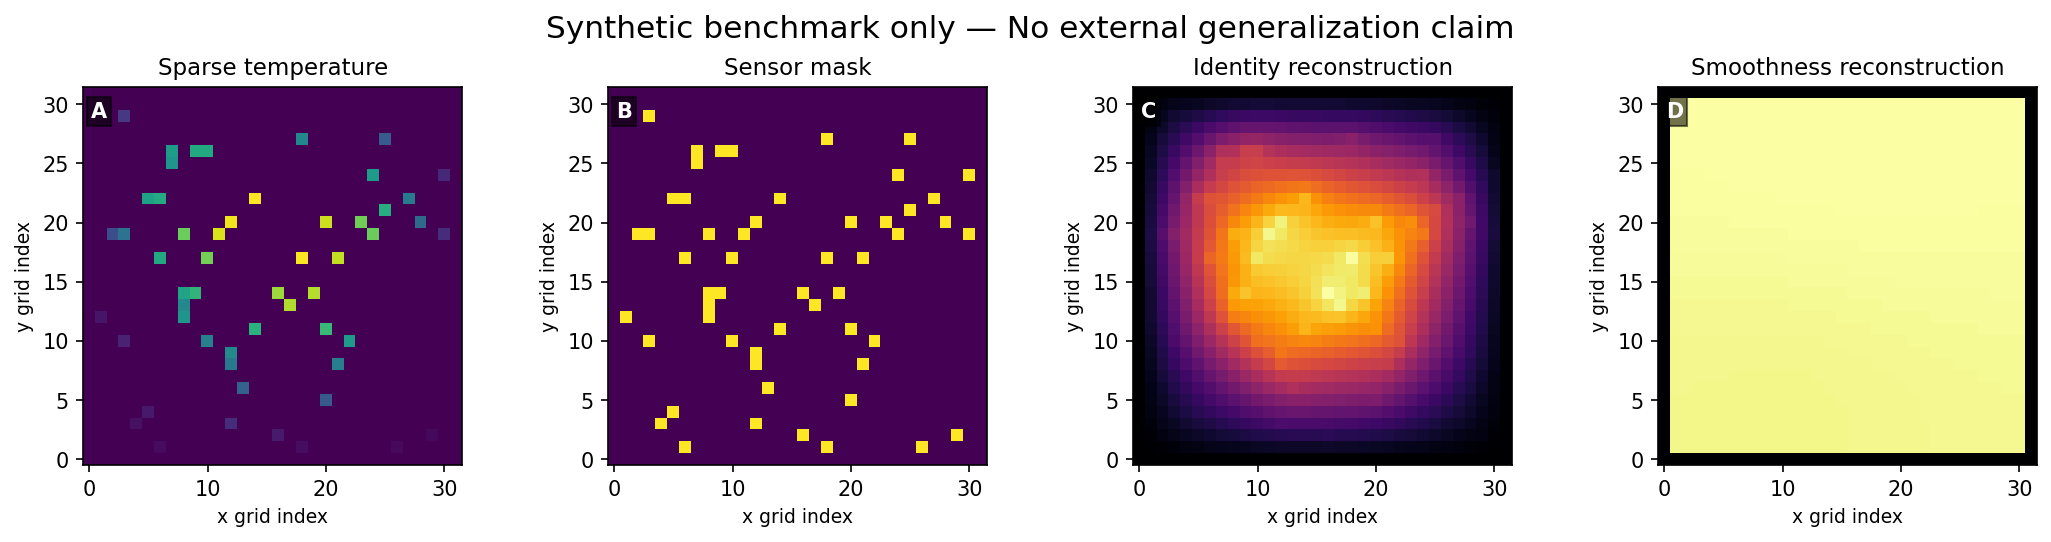

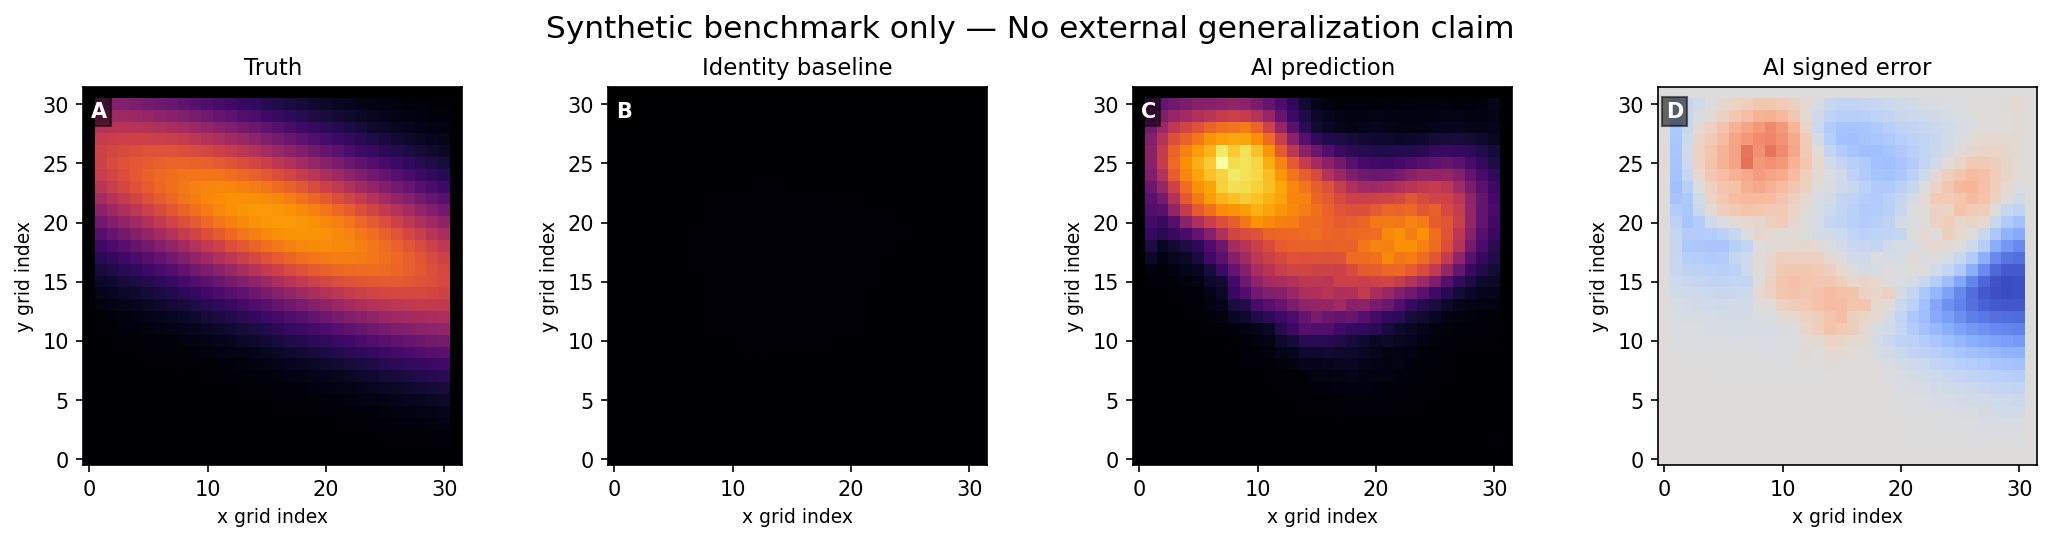

**AI status:** PASS — local inference on representative synthetic sample syn-776fccaf0a9375bdef18a78b

In [16]:
AI_READY=False; AI_DIR=PROJECT_ROOT/'research'/'ai'; DATASET_DIR=PROJECT_ROOT/'data_external'/'phase5_dataset_default'; CHECKPOINT=AI_DIR/'checkpoints'/'task4_default'/'full_residual_attention'/'best.pt'; AGGREGATE=AI_DIR/'outputs'/'evaluation_default'/'aggregate_metrics.csv'; PER_SAMPLE=AI_DIR/'outputs'/'evaluation_default'/'per_sample_metrics.csv'; EVAL_CONFIG=AI_DIR/'configs'/'evaluation_default.json'; MODEL_CONFIG=AI_DIR/'configs'/'model_default.json'
ai_assets=[CHECKPOINT,DATASET_DIR/'manifest.json',DATASET_DIR/'normalization.json',DATASET_DIR/'synthetic_dataset.h5',AGGREGATE,PER_SAMPLE]
def file_hash(path):
    if not path.is_file(): return None
    h=hashlib.sha256()
    with path.open('rb') as stream:
        for block in iter(lambda:stream.read(1024*1024),b''): h.update(block)
    return (path.stat().st_size,path.stat().st_mtime_ns,h.hexdigest())
AI_STATE_BEFORE={str(p):file_hash(p) for p in ai_assets}; missing=[str(p.relative_to(PROJECT_ROOT)) for p in [CHECKPOINT,AGGREGATE,PER_SAMPLE,EVAL_CONFIG,MODEL_CONFIG,DATASET_DIR/'synthetic_dataset.h5'] if not p.exists()]
try: import torch
except ImportError: torch=None
if not RUN_AI_DEMO: reason='RUN_AI_DEMO is False'
elif torch is None: reason='PyTorch unavailable'
elif missing: reason='Missing local assets: '+', '.join(missing)
else:
    try:
        aggregate=pd.read_csv(AGGREGATE); per_sample=pd.read_csv(PER_SAMPLE); methods=['identity','smoothness','full_residual_attention']; ai_aggregate=aggregate[aggregate.method.isin(methods)&aggregate.test_role.eq('test_id')&aggregate.aggregation_type.eq('mean_per_sample')][['method','sample_count','relative_l2']].copy(); ai_aggregate['method']=ai_aggregate.method.map({'identity':'Identity','smoothness':'Smoothness','full_residual_attention':'AI refinement'}); ai_aggregate=ai_aggregate.set_index('method').loc[['Identity','Smoothness','AI refinement']].reset_index(); display(table(ai_aggregate.rename(columns={'method':'Method','sample_count':'Controlled synthetic samples','relative_l2':'Mean relative source error'}),{'Mean relative source error':'{:.2%}'}))
        display(Markdown('The stored AI benchmark compares the learned model with identity and unconstrained smoothness baselines; it does not establish superiority over the recommended smooth-nonnegative classical method.'))
        candidates=per_sample[(per_sample.method=='full_residual_attention')&(per_sample.test_role=='test_id')].copy(); med=float(candidates.relative_l2.median()); selected=str(candidates.assign(d=(candidates.relative_l2-med).abs()).sort_values(['d','sample_id']).iloc[0].sample_id)
        if str(AI_DIR) not in sys.path: sys.path.insert(0,str(AI_DIR))
        from ai_evaluation import EvaluationDataset,dataset_hashes_from_manifest,load_evaluation_config,load_trained_model,predict_sample,validate_evaluation_config
        from ai_model import load_model_config,select_device,validate_model_config
        ec=validate_evaluation_config(dict(load_evaluation_config(EVAL_CONFIG))); mc=validate_model_config(dict(load_model_config(MODEL_CONFIG))); run=next(x for x in ec['model_runs'] if x['name']=='full_residual_attention'); mc['architecture'].update({'attention':run['attention'],'prediction_mode':run['prediction_mode'],'input_channel_mask':run['input_channel_mask']}); mc=validate_model_config(mc); hashes,_=dataset_hashes_from_manifest(DATASET_DIR); ds=EvaluationDataset(DATASET_DIR,'test_id',[selected])
        try: sample,norm=ds[0],ds.normalization
        finally: ds.close()
        device=select_device('cpu'); model=load_trained_model(mc,CHECKPOINT,norm,device,expected_dataset=hashes); prediction=predict_sample(model,sample,norm,device); ai_truth=np.asarray(sample['true_source'],float); inputs=[np.asarray(sample[k],float) for k in ['sparse_temperature','sensor_mask','identity_reconstruction','smoothness_reconstruction']]
        fig,axes=plt.subplots(1,4,figsize=(14,3.5),constrained_layout=True); names=['Sparse temperature','Sensor mask','Identity reconstruction','Smoothness reconstruction']
        for k,(ax,field,name) in enumerate(zip(axes,inputs,names)): im=ax.imshow(field.T,origin='lower',cmap='viridis' if k<2 else 'inferno',interpolation='none'); ax.set(title=name,xlabel='x grid index',ylabel='y grid index'); panel(ax,'ABCD'[k])
        fig.suptitle('Synthetic benchmark only — No external generalization claim'); render(fig,'07_ai_inputs')
        error=prediction-ai_truth; lim=float(np.max(np.abs(error))); vmax=max(float(ai_truth.max()),float(prediction.max())); fig,axes=plt.subplots(1,4,figsize=(14,3.5),constrained_layout=True); fields=[ai_truth,inputs[2],prediction,error]; names=['Truth','Identity baseline','AI prediction','AI signed error']
        for k,(ax,field,name) in enumerate(zip(axes,fields,names)): ax.imshow(field.T,origin='lower',cmap='coolwarm' if k==3 else 'inferno',vmin=-lim if k==3 else 0,vmax=lim if k==3 else vmax,interpolation='none'); ax.set(title=name,xlabel='x grid index',ylabel='y grid index'); panel(ax,'ABCD'[k])
        fig.suptitle('Synthetic benchmark only — No external generalization claim'); render(fig,'08_ai_representative')
        AI_READY=True; reason=f'PASS — local inference on representative synthetic sample {selected}'
    except BaseException as issue:
        if isinstance(issue,(KeyboardInterrupt,SystemExit)): raise
        reason=f'SKIP — {issue}'
AI_STATE_AFTER={str(p):file_hash(p) for p in ai_assets}; assert AI_STATE_AFTER==AI_STATE_BEFORE
record_check('AI future outlook','PASS' if AI_READY else 'SKIP',reason); display(Markdown(f'**AI status:** {reason}'))

### What the user sees
The first figure shows the four stored model inputs: sparse temperature, sensor mask, identity reconstruction, and unconstrained smoothness reconstruction. The second compares synthetic truth, identity baseline, AI prediction, and signed AI error.

### What it means
Across 120 controlled synthetic samples, the learned model reduced aggregate field-level error relative to its stored identity and unconstrained-smoothness baselines. The notebook performs inference only on a model trained previously with 1,200 internally generated samples.

### What it does not prove
The stored AI benchmark does not establish superiority over the recommended smooth-nonnegative method. AI did not improve every metric or every sample. No external data, PDE-based physics loss, experimental validation, or production-readiness claim is present; physical consistency is checked afterward with the classical forward solver.

## 12. Final limitations and next steps

> **Exact or unique recovery is not guaranteed for arbitrary sparse measurements, and real experimental validation remains future work.**

Next steps are external experimental validation, better peak localization, calibrated uncertainty, and transient and heterogeneous physics.

# Appendix — technical evidence and limitations

The following material supports technical questions without interrupting the user story: insufficient-information stress test; rank and singular values; alpha sensitivity; complete-field noise sensitivity; positional detail; environment and safety audit.

## A. Fixed-layout noise robustness

Only the noise realization changes; grid, source, forward temperature, 64 center-focused sensors, method, and alpha remain fixed.

Noise,Median,Minimum,Maximum,Median_residual_RMS
0%,6.25%,6.25%,6.25%,2.691e-05
2%,16.56%,14.97%,19.63%,1.755e-04
5%,32.62%,32.41%,43.68%,4.536e-04


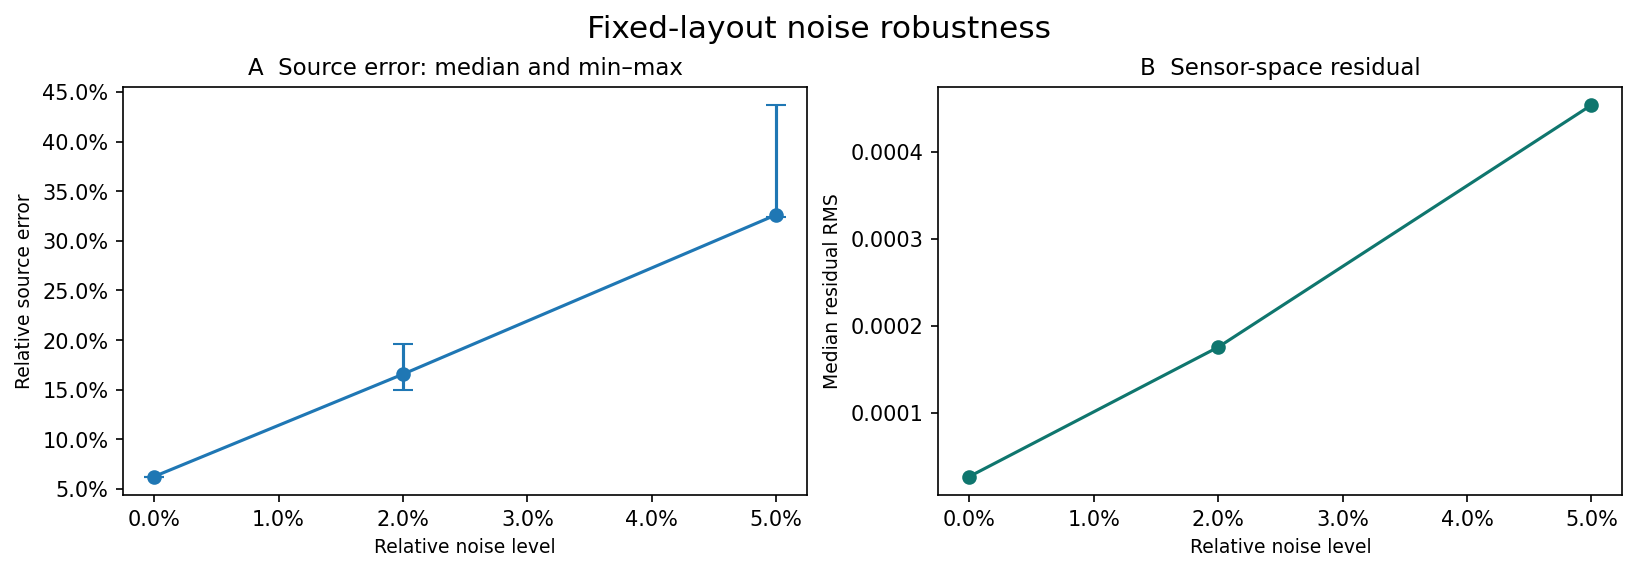

In [17]:
noise_grid=Grid2D(nx=20,ny=20); noise_truth=gaussian_source(noise_grid,center=(.5,.5),amplitude=1,sigma=.08); noise_temperature=solve_forward(noise_truth,noise_grid); noise_ids=center_focused_sensors(noise_grid,count=64,seed=42,include_boundary=False); fixed_clean=create_sensor_data(noise_temperature,noise_ids,noise_grid); noise_rows=[]
for level in (0,.02,.05):
    for seed in (10,20,30):
        noisy=add_noise_to_sensor_data(fixed_clean,level,seed=seed,relative=True); rec=reconstruct_smooth_tikhonov(noisy,noise_grid,alpha=1e-9,nonnegative=True); m=metrics_with_truth(noise_truth,rec,noisy.values); noise_rows.append({'Noise':level,'Seed':seed,'Relative source error':m['relative_l2_error'],'Sensor residual RMS':m['residual_rms']})
noise_detail=pd.DataFrame(noise_rows); noise_summary=noise_detail.groupby('Noise',sort=False).agg(Median=('Relative source error','median'),Minimum=('Relative source error','min'),Maximum=('Relative source error','max'),Median_residual_RMS=('Sensor residual RMS','median')).reset_index(); display(table(noise_summary,{'Noise':'{:.0%}','Median':'{:.2%}','Minimum':'{:.2%}','Maximum':'{:.2%}','Median_residual_RMS':'{:.3e}'}))
lo=noise_summary.Median-noise_summary.Minimum; hi=noise_summary.Maximum-noise_summary.Median; fig,axes=plt.subplots(1,2,figsize=(10.8,3.7),constrained_layout=True); axes[0].errorbar(noise_summary.Noise,noise_summary.Median,yerr=np.vstack([lo,hi]),marker='o',capsize=5); axes[0].xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1)); axes[0].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1)); axes[0].set(title='A  Source error: median and min–max',xlabel='Relative noise level',ylabel='Relative source error'); axes[1].plot(noise_summary.Noise,noise_summary.Median_residual_RMS,'o-',color='#0f766e'); axes[1].xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1)); axes[1].set(title='B  Sensor-space residual',xlabel='Relative noise level',ylabel='Median residual RMS'); fig.suptitle('Fixed-layout noise robustness'); render(fig,'appendix_noise_robustness')
assert np.allclose(noise_summary.Median,[.0625,.1656,.3262],atol=.002) and abs(noise_summary.loc[noise_summary.Noise==.05,'Maximum'].iloc[0]-.4368)<.002; record_check('Noise robustness','PASS','0%, 2%, and 5% fixed-layout study reproduced across three noise seeds.')

Source error rises from 6.25% without noise to 16.56% at 2% and 32.62% at 5% median performance; the 5% maximum reaches 43.68%. Source recovery is more noise-sensitive than sensor-space fit. Three realizations demonstrate sensitivity, not publication-level uncertainty.

## B. When sparse information is insufficient

A low sensor-space residual does not prove accurate source recovery.

Sensors,Unknowns,Relative source error,Relative sensor residual,Rank,Nullity,Minimum source
16,324,53.0%,0.52%,16,308,-0.239


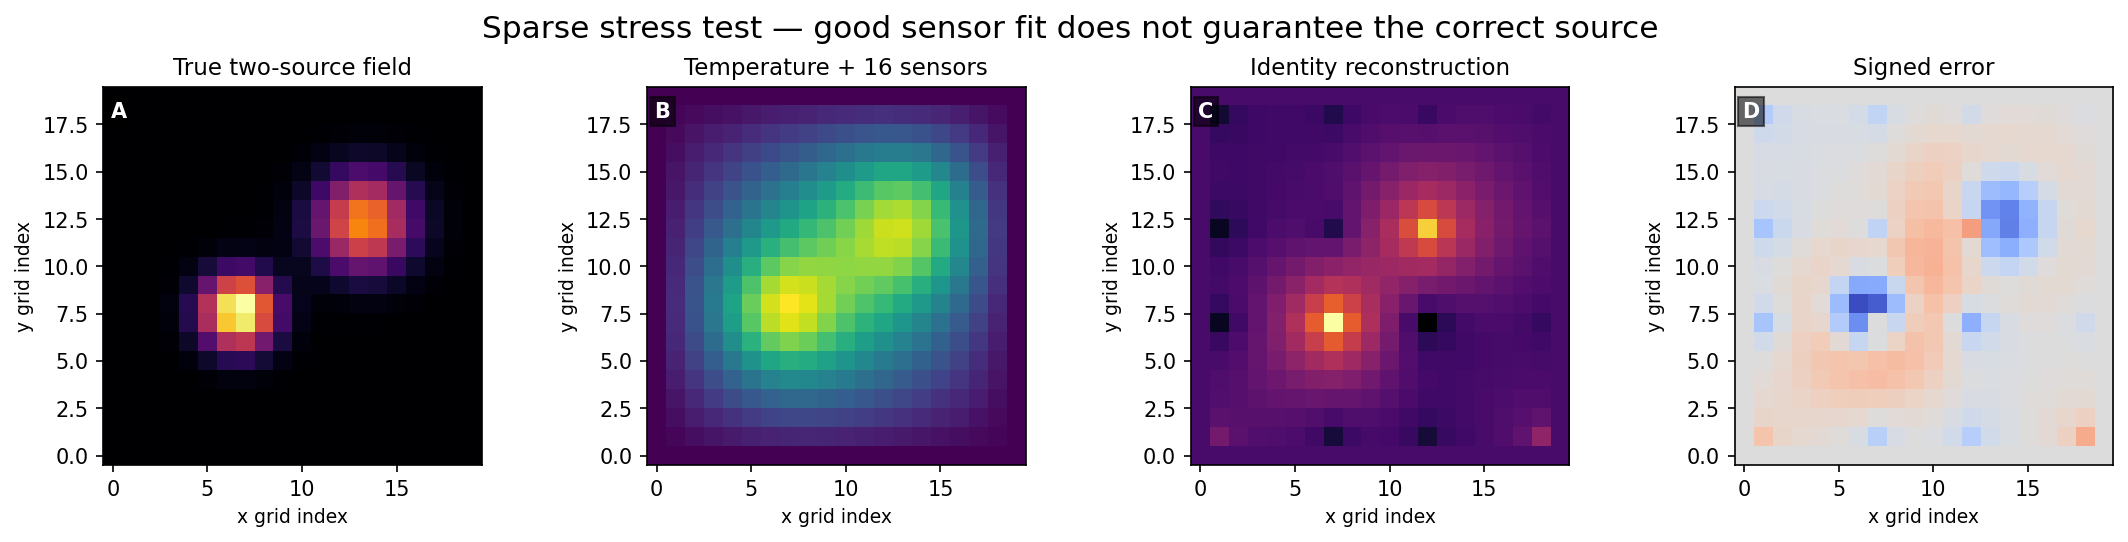

In [18]:
stress=run_synthetic_benchmark(grid_shape=(20,20),source_type='two_gaussians',sensor_strategy='regular',num_sensors=16,noise_level=.02,alpha=1e-7,regularization='identity',seed=42); diag=analyze_observation_matrix(build_observation_matrix(stress.sensor_data_noisy.indices,stress.grid))
stress_table=pd.DataFrame([{'Sensors':16,'Unknowns':324,'Relative source error':stress.metrics['relative_l2_error'],'Relative sensor residual':stress.metrics['relative_residual'],'Rank':diag['numerical_rank'],'Nullity':diag['nullity'],'Minimum source':float(stress.reconstructed_source[1:-1,1:-1].min())}]); display(table(stress_table,{'Relative source error':'{:.1%}','Relative sensor residual':'{:.2%}','Minimum source':'{:.3f}'}))
truth,estimate=stress.true_source,stress.reconstructed_source; err=estimate-truth; lim=float(np.max(np.abs(err))); vmax=max(float(truth.max()),float(estimate.max())); fig,axes=plt.subplots(1,4,figsize=(14.5,3.5),constrained_layout=True); fields=[truth,stress.temperature,estimate,err]; names=['True two-source field','Temperature + 16 sensors','Identity reconstruction','Signed error']
for k,(ax,field,name) in enumerate(zip(axes,fields,names)): ax.imshow(field.T,origin='lower',cmap='coolwarm' if k==3 else ('viridis' if k==1 else 'inferno'),vmin=-lim if k==3 else None,vmax=lim if k==3 else None,interpolation='none'); ax.set(title=name,xlabel='x grid index',ylabel='y grid index'); panel(ax,'ABCD'[k])
fig.suptitle('Sparse stress test — good sensor fit does not guarantee the correct source'); render(fig,'appendix_sparse_stress')
assert abs(stress.metrics['relative_l2_error']-.529918)<.002 and diag['numerical_rank']==16 and diag['nullity']==308; record_check('Sparse stress test','PASS','53% source error with 0.52% sensor residual; rank 16, nullity 308.')

## C. Extended numerical evidence

The matched-model clean result is a **numerical consistency check only**, not realistic experimental accuracy. The noisy complete-field comparison is sensitivity evidence rather than a causal sensor-count study.

**Matched-model numerical consistency check only — not real experimental accuracy:** relative source error = 0.0009%

Case,Measurements,Synthetic relative source error,Sensor residual RMS
324 noisy,324,25.37%,2.236e-04
64 noisy,64,48.85%,8.170e-05
8 noisy,8,90.48%,8.524e-06


**Full alpha table**

Alpha,Relative source error,Sensor residual RMS
1.0e-12,105.74%,1.388e-04
1.0e-11,73.01%,1.402e-04
1.0e-10,47.16%,1.478e-04
1.0e-09,18.54%,1.798e-04
1.0e-08,23.95%,2.554e-04
1.0e-07,49.02%,5.180e-04


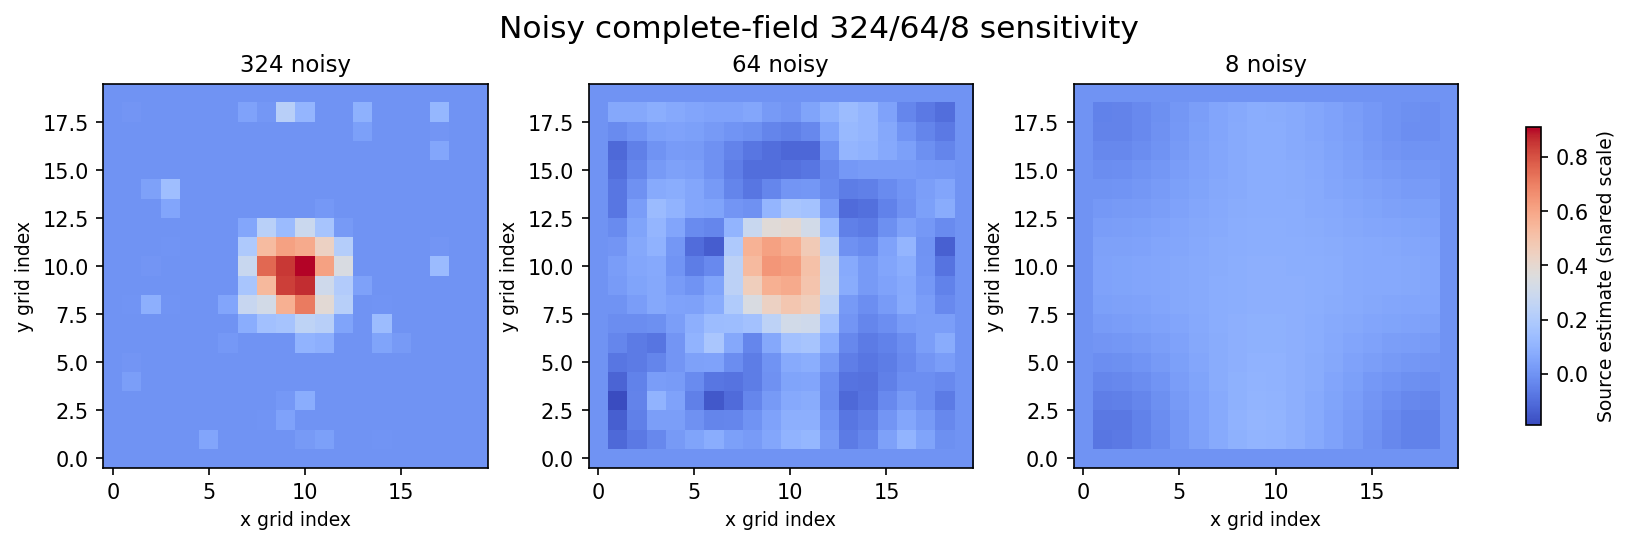

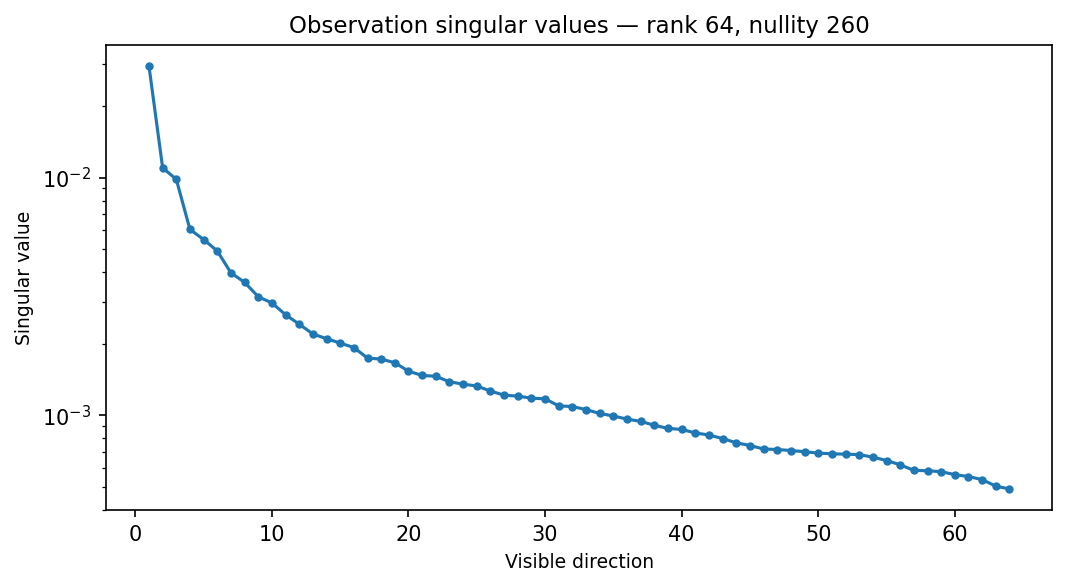

In [19]:
clean_check=reconstruct_from_temperature_field(clean_field,grid=field_grid,alpha=1e-10,regularization='identity'); clean_error=compute_all_metrics(field_truth,clean_check.reconstructed_source)['relative_l2_error']
ids64=regular_grid_sensors(field_grid,64); ids8=np.array([(2,2),(2,9),(2,17),(9,2),(9,17),(17,2),(17,9),(17,17)]); f64=reconstruct_from_temperature_field(noisy_field,grid=field_grid,sensor_indices=ids64,alpha=1e-9,regularization='smoothness'); f8=reconstruct_from_temperature_field(noisy_field,grid=field_grid,sensor_indices=ids8,alpha=1e-9,regularization='smoothness')
sensitivity=[]
for name,res in [('324 noisy',field_result),('64 noisy',f64),('8 noisy',f8)]: sensitivity.append({'Case':name,'Measurements':len(res.sensor_data),'Synthetic relative source error':compute_all_metrics(field_truth,res.reconstructed_source)['relative_l2_error'],'Sensor residual RMS':residual_rms(res.reconstruction.predicted_measurements,res.sensor_data.values)})
display(Markdown(f'**Matched-model numerical consistency check only — not real experimental accuracy:** relative source error = {clean_error:.4%}')); display(table(pd.DataFrame(sensitivity),{'Synthetic relative source error':'{:.2%}','Sensor residual RMS':'{:.3e}'})); display(Markdown('**Full alpha table**')); display(table(alpha_study,{'Alpha':'{:.1e}','Relative source error':'{:.2%}','Sensor residual RMS':'{:.3e}'}))
sensitivity_sources=[field_result.reconstructed_source,f64.reconstructed_source,f8.reconstructed_source]; smin=min(float(x.min()) for x in sensitivity_sources); smax=max(float(x.max()) for x in sensitivity_sources); fig,axes=plt.subplots(1,3,figsize=(10.8,3.5),constrained_layout=True)
for ax,field,name in zip(axes,sensitivity_sources,['324 noisy','64 noisy','8 noisy']): im=ax.imshow(field.T,origin='lower',cmap='coolwarm',vmin=smin,vmax=smax,interpolation='none'); ax.set(title=name,xlabel='x grid index',ylabel='y grid index')
fig.colorbar(im,ax=axes.tolist(),shrink=.72,label='Source estimate (shared scale)'); fig.suptitle('Noisy complete-field 324/64/8 sensitivity'); render(fig,'appendix_field_sensitivity')
obs=build_observation_matrix(showcase_base.sensor_data_noisy.indices,showcase_base.grid); od=analyze_observation_matrix(obs); sv=np.asarray(od['singular_values'])[:od['numerical_rank']]
fig,ax=plt.subplots(figsize=(7,3.8),constrained_layout=True); ax.semilogy(np.arange(1,len(sv)+1),sv,'o-',ms=3); ax.set(title=f'Observation singular values — rank {od["numerical_rank"]}, nullity {od["nullity"]}',xlabel='Visible direction',ylabel='Singular value'); render(fig,'appendix_singular_values')
record_check('Extended evidence','PASS',f'Clean consistency {clean_error:.4%}; noisy 324/64/8, singular values, and full alpha table rendered.')

## D. MC-dropout predictive dispersion

> **Synthetic benchmark only — No external generalization claim**

Passes,Predictive-mean relative error,Mean predictive std,Maximum predictive std,"Spearman(std, absolute error)"
10,33.90%,1.085e-01,3.439e-01,0.615


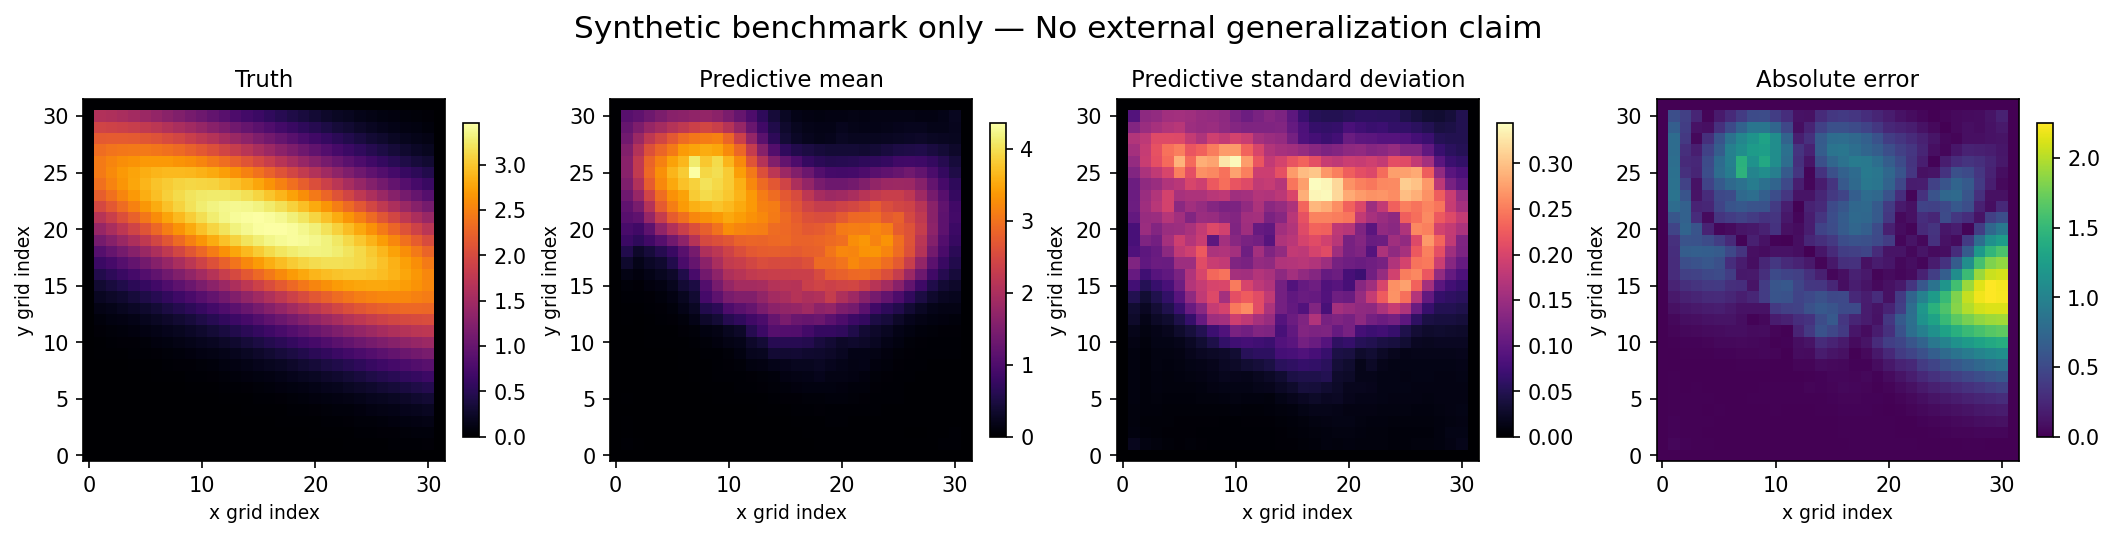

In [20]:
if not AI_READY:
    record_check('AI predictive dispersion','SKIP','AI inference was unavailable.')
    display(Markdown('**SKIP:** AI inference was unavailable, so predictive dispersion was not computed.'))
else:
    from ai_evaluation import mc_dropout_prediction,source_metrics,spearman_correlation
    mc_passes=10; predictive_mean,predictive_std=mc_dropout_prediction(model,sample,norm,device,passes=mc_passes,seed=4242); absolute_error=np.abs(predictive_mean-ai_truth); mask=np.asarray(sample['source_valid_mask'],bool); corr=spearman_correlation(predictive_std[mask],absolute_error[mask]); mc_metrics=source_metrics(predictive_mean,ai_truth,mask)
    mc_table=pd.DataFrame([{'Passes':mc_passes,'Predictive-mean relative error':mc_metrics['relative_l2'],'Mean predictive std':float(predictive_std[mask].mean()),'Maximum predictive std':float(predictive_std[mask].max()),'Spearman(std, absolute error)':corr}]); display(table(mc_table,{'Predictive-mean relative error':'{:.2%}','Mean predictive std':'{:.3e}','Maximum predictive std':'{:.3e}','Spearman(std, absolute error)':'{:.3f}'}))
    fig,axes=plt.subplots(1,4,figsize=(14,3.5),constrained_layout=True); fields=[ai_truth,predictive_mean,predictive_std,absolute_error]; names=['Truth','Predictive mean','Predictive standard deviation','Absolute error']; maps=['inferno','inferno','magma','viridis']
    for ax,field,name,cmap in zip(axes,fields,names,maps): im=ax.imshow(field.T,origin='lower',cmap=cmap,interpolation='none'); ax.set(title=name,xlabel='x grid index',ylabel='y grid index'); fig.colorbar(im,ax=ax,shrink=.7)
    fig.suptitle('Synthetic benchmark only — No external generalization claim'); render(fig,'appendix_mc_dropout'); record_check('AI predictive dispersion','PASS',f'{mc_passes} deterministic passes; dispersion/error correlation {corr:.3f}.')
AI_STATE_AFTER_MC={str(p):file_hash(p) for p in ai_assets}; assert AI_STATE_AFTER_MC==AI_STATE_BEFORE

The standard-deviation map is a predictive-instability indicator from ten deterministic dropout passes. It is not a Bayesian posterior, calibrated uncertainty, or evidence of external generalization.

## E. Reproducibility, environment, and safety audit

In [21]:
checks=pd.DataFrame(demo_checks); display(table(checks))
required=['Table visibility','Physics model','Architecture','Synthetic showcase','Method choice','Alpha sensitivity','Sensor planning','Positional robustness','Information reduction','External CSV','Complete field','Reporting','Noise robustness','Sparse stress test','Extended evidence']; assert checks.set_index('Section').loc[required,'Status'].eq('PASS').all(); assert checks.loc[checks.Section.isin(['AI future outlook','AI predictive dispersion']),'Status'].isin(['PASS','SKIP']).all()
environment=pd.DataFrame([('Python',platform.python_version()),('Platform',platform.platform()),('NumPy',np.__version__),('SciPy',scipy.__version__),('pandas',pd.__version__),('Matplotlib',matplotlib.__version__),('PyTorch',getattr(torch,'__version__','not installed'))],columns=['Component','Version / status']); display(table(environment))
inventory=[]
if CURRENT_RUN_ROOT.exists():
    for p in sorted(x for x in CURRENT_RUN_ROOT.rglob('*') if x.is_file()): inventory.append({'Relative path':p.relative_to(CURRENT_RUN_ROOT).as_posix(),'Bytes':p.stat().st_size})
output_inventory=pd.DataFrame(inventory); display(table(output_inventory))
print('Previously verified reference: 643 classical tests passed; 228 AI tests passed. Not rerun by instruction.')
print('AI safety: inference only; no training, dataset construction, download, network, install, checkpoint write, or dataset write.')
print('All generated output paths are below:',CURRENT_RUN_ROOT)


Section,Status,Detail
Table visibility,PASS,Global cross-renderer CSS executed before the first DataFrame output.
Physics model,PASS,"Equation, boundary, five-point stencil, and 324-unknown interpretation rendered."
Architecture,PASS,Workflow-to-module mapping rendered.
Synthetic showcase,PASS,Median 18.54%; largest tested 23.63%; peak median 1.0 cell.
Method choice,PASS,Smooth nonnegative is the recommended simpler and faster physical method here.
Alpha sensitivity,PASS,1e-9 is the best tested alpha for this exact configuration.
Sensor planning,PASS,Budget and positional layout studies reproduced.
Positional robustness,PASS,Four source positions × three layouts × three seeds rendered.
Information reduction,PASS,324/64/16 measurement comparison rendered with common and symmetric limits.
External CSV,PASS,16 sensors; residual RMS 7.059e-05; no truth-based source metrics.


Component,Version / status
Python,3.10.11
Platform,Windows-10-10.0.26200-SP0
NumPy,2.2.6
SciPy,1.15.3
pandas,2.3.3
Matplotlib,3.10.9
PyTorch,2.11.0+cu128


Relative path,Bytes
figures/01_architecture_workflow.png,135567
figures/02_physics_grid_stencil.png,58357
figures/02_targeted_showcase.png,115314
figures/03_method_choice.png,49749
figures/04_alpha_sensitivity.png,83548
figures/04_external_csv.png,99811
figures/05_complete_field.png,111682
figures/05_sensor_planning.png,130195
figures/06_positional_robustness.png,113544
figures/07_ai_inputs.png,50209


Previously verified reference: 643 classical tests passed; 228 AI tests passed. Not rerun by instruction.
AI safety: inference only; no training, dataset construction, download, network, install, checkpoint write, or dataset write.
All generated output paths are below: <repository root>\outputs\notebook_demo\presentation_final
